# PEMS-PINN de CO — evaluación walk-forward final

**Versión:** R3F_STD  
**Estado:** FINAL; consume `WF_PROTOCOL_R1` y `CO_WF_OPT_R3_POC_EFFICIENT` en estado `FROZEN`.  
**Propósito:** entrenar diez modelos con todo DEV 2011–2014 y evaluar una sola
vez la frontera prospectiva `WF04: 2011–2014 → 2015`.  
**Entorno previsto:** Google Colab con GPU y ejecución **Run all**.  
**Entradas:** protocolo WF R1, handoff y configuración congelada del OPT R3.  
**Salidas:** checkpoints por semilla, predicciones 2015, métricas predictivas y
físicas, ensamble aritmético predeclarado, figuras, huella y manifiesto final.

El notebook no ejecuta Optuna ni reabre arquitectura, hiperparámetros, épocas,
semillas o pesos del ensamble. Ningún valor de 2015 se materializa hasta que los
diez checkpoints DEV-only hayan sido escritos, recargados y autenticados por la
puerta `PRE_TEST_GATE`.

## Mapa del notebook

| Sección | Finalidad |
|---|---|
| SEC-00 | alcance, reglas y mapa |
| SEC-01 | entorno, rutas y reproducibilidad |
| SEC-02 | verificación del protocolo y handoff FROZEN |
| SEC-03 | carga exclusiva de DEV 2011–2014 |
| SEC-04 | núcleo científico idéntico al OPT R3 |
| SEC-05 | controles previos |
| SEC-06 | entrenamiento multisemilla con todo DEV |
| SEC-07 | gate irreversible y apertura única de 2015 |
| SEC-08 | evaluación por semilla y ensamble |
| SEC-09 | figuras y huella computacional |
| SEC-10 | persistencia, manifiesto y cierre |

### Reglas predeclaradas

1. Todos los escaladores, cuantiles, kNN, sintéticos y pesos usan solo DEV.
2. `FINAL_EPOCHS` procede de 15 observaciones DEV del campeón confirmado.
3. Se entrenan diez semillas congeladas antes de 2015.
4. `gt_2015.csv` se materializa una sola vez después del gate y se hashea entonces.
5. El ensamble es la media aritmética de las diez predicciones, sin selección post hoc.
6. La semilla 42 es representativa para figuras; no se elige con TEST.

El resultado mide transferencia prospectiva a 2015 dentro del horizonte estudiado;
no implica causalidad ni certificación regulatoria.


## SEC-01 — Entorno y configuración de ejecución

La única ruta editable es `PROJECT_ROOT_PATH`. El perfil final siempre ejecuta las
diez semillas congeladas; no existe un modo que produzca resultados parciales con
apariencia de evaluación final.

### C-01.01 — Acceso a Drive y dependencias

**Objetivo:** preparar un runtime limpio y verificar las bibliotecas requeridas.  
**Entradas:** raíz canónica del proyecto.  
**Salidas:** entorno listo para PyTorch.  
**Fallo:** instalación o montaje no disponible.


In [1]:
# [C-01.01] Acceso a Drive y dependencias
PROJECT_ROOT_PATH = "C:\\ChatGPT-Work\\Walk_Forward R8"

import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_PACKAGES = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "psutil": "psutil",
    "sklearn": "scikit-learn",
    "torch": "torch",
}
missing_packages = [
    package
    for module, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

print(
    {
        "entorno": "Google Colab" if IN_COLAB else "local",
        "paquetes_instalados": missing_packages,
    }
)


{'entorno': 'local', 'paquetes_instalados': []}


### C-01.02 — Constantes científicas y contrato de rutas

**Objetivo:** declarar una sola fuente de verdad para nombres, semillas y destinos.  
**Entradas:** decisiones congeladas de PROTOCOL R1 y OPT R3.  
**Salidas:** constantes y estructura de carpetas del notebook FINAL.  
**Control:** el único modo físico autorizado es `CDP_NEG`; no se infieren rutas.


In [2]:
# [C-01.02] Constantes científicas y contrato de rutas
import contextlib
import copy
import hashlib
import io
import importlib.metadata
import json
import math
import os
import platform
import random
import tempfile
import time
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

VERSION = "CO_WF_FINAL_R3F_STD"
PROTOCOL_VERSION = "WF_PROTOCOL_R1"
OPT_VERSION = "CO_WF_OPT_R3_POC_EFFICIENT"
EXPECTED_CAMPAIGN_SCHEMA = (
    "R3_ALL_THREE_WF_FOLDS_STOP_V3_CDP_NEG_FIXED_EPOCHS"
)
PROTOCOL_NOTEBOOK_NAME = "00_PEMS_PINN_WF_PROTOCOL - R1.ipynb"
OPT_NOTEBOOK_NAME = (
    "04_Gold_Standard_PINN_CO_WF_OPT - R3_POC_EFFICIENT.ipynb"
)
CURRENT_NOTEBOOK_NAME = (
    "04_Gold_Standard_PINN_CO_WF_FINAL - R3F_STD.ipynb"
)
FEATURES = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "TEY", "CDP"]
TARGET = "CO"
PHYSICS_MODE = "CDP_NEG"
PHYSICS_FEATURE = "CDP"
MONOTONIC_CONSTRAINT = "dCO_dCDP_le_0"
PHYSICS_SCALE_QUANTILES = (0.05, 0.95)
PHYSICS_SCALE_POLICY = "FOLD_TRAIN_Q95_MINUS_Q05"
DEVELOPMENT_YEARS = [2011, 2012, 2013, 2014]
FINAL_TEST_YEAR = 2015
YEARS = [*DEVELOPMENT_YEARS, FINAL_TEST_YEAR]
EXPECTED_FINAL_SEEDS = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210]
EXPECTED_STOP_POLICY = {
    "stop_policy_version": "POC_EFFICIENT_STOP_POLICY_V3",
    "minimum_attempted_trials": 30,
    "minimum_complete_total_trials": 12,
    "minimum_complete_optuna_trials": 8,
    "minimum_competitive_trials": 3,
    "competitive_band_delta": 0.010,
    "competitive_band_role": "PRIMARY_STOP_WITH_HARD_CAP_TOP3_FALLBACK",
    "material_gain": 0.002,
    "elite_band_delta": 0.003,
    "elite_band_role": "DIAGNOSTIC_ONLY",
    "hard_cap_fallback_mode": "HIERARCHICAL_TOP3_MANDATORY_CONFIRMATION",
    "hard_cap_fallback_min_admissible": 3,
}
EXPECTED_ADAPTIVE_BLOCK_SIZE = 5
EXPECTED_ADAPTIVE_PATIENCE_BLOCKS = 2
EXPECTED_HARD_CAP = 55
REPRESENTATIVE_SEED = 42
ENSEMBLE_RULE = "arithmetic_mean_over_frozen_seed_predictions"
PHYSICS_EVAL_ROWS = 2048
EPS_DIMENSIONLESS = 1e-6
MAX_TRAINABLE_PARAMETERS = 350_000
LATENCY_WARMUP = 20
LATENCY_REPETITIONS = 200
THROUGHPUT_WARMUP = 5
THROUGHPUT_REPETITIONS = 30
TF32 = True

PROTOCOL_REL = Path("models") / "wf" / "work_pinn_wf_protocol"
OPT_REL = (
    Path("models")
    / "wf"
    / "work_pinn_co_wf_opt_r3_poc_efficient"
)
OUTPUT_REL = (
    Path("models") / "wf" / "work_pinn_co_wf_final_r3_std"
)


@dataclass(frozen=True)
class FinalPaths:
    """Rutas persistentes del entregable FINAL."""

    root: Path
    work: Path
    audit: Path
    configs: Path
    tables: Path
    figures_test: Path
    figures_summary: Path
    models: Path
    reports: Path


def make_paths(root: Path) -> FinalPaths:
    """Crea únicamente la estructura canónica de salida FINAL."""
    work = root / OUTPUT_REL
    paths = FinalPaths(
        root=root,
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        tables=work / "tables",
        figures_test=work / "figures" / "test",
        figures_summary=work / "figures" / "summary",
        models=work / "models",
        reports=work / "reports",
    )
    for key, value in asdict(paths).items():
        if key != "root":
            Path(value).mkdir(parents=True, exist_ok=True)
    return paths


### C-01.03 — Utilidades reproducibles y entorno computacional

**Objetivo:** centralizar semillas, hashes y escrituras atómicas.  
**Entradas:** archivos y objetos persistentes.  
**Salidas:** funciones de integridad y manifiesto del entorno.  
**Control:** los archivos incompletos no reemplazan una versión válida.


In [3]:
# [C-01.03] Utilidades reproducibles y entorno computacional
def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def canonical_json(value: Any) -> str:
    return json.dumps(
        value,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )


def sha256_bytes(value: bytes) -> str:
    return hashlib.sha256(value).hexdigest()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def config_hash(config: dict) -> str:
    payload = {key: value for key, value in config.items() if key != "config_hash"}
    return sha256_bytes(canonical_json(payload).encode("utf-8"))


def atomic_text(path: Path, text: str) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    descriptor, temporary_name = tempfile.mkstemp(
        prefix=path.name + ".",
        suffix=".tmp",
        dir=path.parent,
    )
    os.close(descriptor)
    temporary_path = Path(temporary_name)
    try:
        temporary_path.write_text(text, encoding="utf-8", newline="\n")
        os.replace(temporary_path, path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()


def atomic_json(path: Path, value: Any) -> None:
    atomic_text(
        path,
        json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False, default=str)
        + "\n",
    )


def atomic_csv(path: Path, frame: pd.DataFrame) -> None:
    atomic_text(path, frame.to_csv(index=False, lineterminator="\n"))


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except RuntimeError:
        pass


def select_device() -> torch.device:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        torch.backends.cuda.matmul.allow_tf32 = TF32
        torch.backends.cudnn.allow_tf32 = TF32
    return device


def environment_manifest(device: torch.device) -> dict:
    return {
        "generated_at_utc": utc_now(),
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": importlib.metadata.version("scikit-learn"),
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "device": str(device),
        "gpu_name": (
            torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
        ),
        "logical_cpu_count": psutil.cpu_count(logical=True),
        "ram_gib": round(psutil.virtual_memory().total / 2**30, 3),
        "tf32": TF32,
        "deterministic_algorithms": "warn_only",
    }


### C-01.04 — Inicialización controlada

**Objetivo:** validar la raíz declarada, seleccionar dispositivo y registrar entorno.  
**Entradas:** `PROJECT_ROOT_PATH`.  
**Salidas:** `PROJECT_ROOT`, `PATHS`, `DEVICE`.  
**Fallo:** ausencia de los notebooks o contratos FROZEN upstream requeridos.


In [4]:
# [C-01.04] Inicialización controlada
def validate_project_root(project_root_path: str | Path) -> Path:
    """Valida la estructura canónica sin buscar copias alternativas."""
    root = Path(project_root_path).expanduser()
    if not root.is_absolute():
        raise ValueError("PROJECT_ROOT_PATH debe ser una ruta absoluta")
    root = root.resolve()
    required = [
        root / "notebooks" / PROTOCOL_NOTEBOOK_NAME,
        root / "notebooks" / OPT_NOTEBOOK_NAME,
        root / PROTOCOL_REL,
        root / OPT_REL,
    ]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "La raíz configurada no contiene la estructura requerida:\n- "
            + "\n- ".join(missing)
        )
    return root


PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
PATHS = make_paths(PROJECT_ROOT)
DEVICE = select_device()
ENVIRONMENT = environment_manifest(DEVICE)
atomic_json(PATHS.audit / "ENVIRONMENT_CO_WF_FINAL_R3F_STD.json", ENVIRONMENT)

display(
    pd.Series(
        {
            "versión": VERSION,
            "dispositivo": str(DEVICE),
            "raíz": str(PROJECT_ROOT),
            "entrada PROTOCOL": str(PROJECT_ROOT / PROTOCOL_REL),
            "entrada OPT": str(PROJECT_ROOT / OPT_REL),
            "salida FINAL": str(PATHS.work),
            "semillas esperadas": EXPECTED_FINAL_SEEDS,
            "semilla representativa": REPRESENTATIVE_SEED,
        },
        name="valor",
    ).to_frame()
)


,valor
versión,CO_WF_FINAL_R3F_STD
dispositivo,cuda
raíz,C:\ChatGPT-Work\Walk_Forward R8
entrada PROTOCOL,C:\ChatGPT-Work\Walk_Forward R8\models\wf\work...
entrada OPT,C:\ChatGPT-Work\Walk_Forward R8\models\wf\work...
salida FINAL,C:\ChatGPT-Work\Walk_Forward R8\models\wf\work...
semillas esperadas,"[21, 42, 63, 84, 105, 126, 147, 168, 189, 210]"
semilla representativa,42


## SEC-02 — Verificación cruzada de entradas `FROZEN`

Esta sección constituye `CHK-02`. Antes de materializar cualquier valor de CO se
verifican el protocolo, la asignación, los folds, los cuatro CSV DEV por hash y solo el encabezado de 2015, la campaña R3, la
configuración ganadora, la política de épocas y el handoff. Cualquier discrepancia
detiene la ejecución; el notebook no repara ni sustituye artefactos.

#### ALG-01 — Contrato de entrada FINAL

1. verificar estado, versión y hashes de los manifiestos;
2. comprobar todos los artefactos declarados por OPT R3;
3. verificar `STOP_POLICY_V3` y la razón terminal de la campaña;
4. comprobar que TEST no fue abierto en OPT;
5. exigir `physics_mode=CDP_NEG`, `physics_feature=CDP` y el contrato de signo;
6. comprobar parámetros fijos, configuración, política y semillas congeladas.

### C-02.01 — Verificación integral de protocolo y handoff

**Entradas:** artefactos persistidos por PROTOCOL R1 y OPT R3.  
**Salidas:** asignación, manifiestos, configuración y política verificadas.  
**Fallo:** cualquier ausencia, hash distinto, modo distinto o estado no `FROZEN`.


In [5]:
# [C-02.01] Verificación integral de protocolo y handoff WF
def read_json(path: Path) -> dict:
    return json.loads(Path(path).read_text(encoding="utf-8"))


def verify_stop_policy_contract(frozen_opt: dict, campaign_state: dict) -> dict:
    """Acepta gates primarios o fallback Top-3; nunca un atajo a FROZEN."""
    expected = {
        "stop_policy_version": "POC_EFFICIENT_STOP_POLICY_V3",
        "minimum_attempted_trials": 30,
        "minimum_complete_total_trials": 12,
        "minimum_complete_optuna_trials": 8,
        "minimum_competitive_trials": 3,
        "competitive_band_delta": 0.010,
        "material_gain": 0.002,
        "elite_band_delta": 0.003,
        "adaptive_block_size": 5,
        "adaptive_patience_blocks": 2,
        "maximum_attempted_trials": 55,
        "fold_execution_policy": "ALL_THREE_WF_FOLDS_FULL_EVAL",
        "hard_cap_fallback_mode": "HIERARCHICAL_TOP3_MANDATORY_CONFIRMATION",
        "hard_cap_fallback_min_admissible": 3,
    }
    observed = {
        "stop_policy_version": frozen_opt.get("stop_policy_version"),
        "minimum_attempted_trials": frozen_opt.get("minimum_attempted_trials"),
        "minimum_complete_total_trials": frozen_opt.get(
            "minimum_complete_total_trials"
        ),
        "minimum_complete_optuna_trials": frozen_opt.get(
            "minimum_complete_optuna_trials"
        ),
        "minimum_competitive_trials": frozen_opt.get(
            "minimum_competitive_trials"
        ),
        "competitive_band_delta": frozen_opt.get("competitive_band_delta"),
        "material_gain": frozen_opt.get("material_gain"),
        "elite_band_delta": frozen_opt.get("elite_band_delta"),
        "adaptive_block_size": campaign_state.get("adaptive_block_size"),
        "adaptive_patience_blocks": campaign_state.get(
            "adaptive_patience_blocks"
        ),
        "maximum_attempted_trials": campaign_state.get(
            "maximum_attempted_trials"
        ),
        "fold_execution_policy": frozen_opt.get("fold_execution_policy"),
        "hard_cap_fallback_mode": frozen_opt.get("hard_cap_fallback_mode"),
        "hard_cap_fallback_min_admissible": frozen_opt.get(
            "hard_cap_fallback_min_admissible"
        ),
    }
    if observed != expected:
        raise RuntimeError(f"Política OPT R3 incompatible: {observed}")
    if frozen_opt.get("development_evidence_source") != "FRESH_R3_SEARCH":
        raise RuntimeError("OPT R3 no declara una búsqueda CO nativa")
    if campaign_state.get("development_evidence_source") != "FRESH_R3_SEARCH":
        raise RuntimeError("campaign_state no declara una búsqueda CO nativa")
    if frozen_opt.get("physics_scale_policy") != PHYSICS_SCALE_POLICY:
        raise RuntimeError("FROZEN no declara escalas físicas fold-train robustas")
    if campaign_state.get("physics_scale_policy") != PHYSICS_SCALE_POLICY:
        raise RuntimeError("campaign_state no declara escalas fold-train")

    stop_reason = campaign_state.get("stop_reason")
    allowed_reasons = {
        "PRACTICAL_PLATEAU",
        "HARD_CAP",
        "HARD_CAP_TOP3_CONFIRMATION_FALLBACK",
    }
    if stop_reason not in allowed_reasons:
        raise RuntimeError("OPT R3 no declaró una razón terminal autorizada")
    frozen_gates = frozen_opt.get("evidence_gates")
    state_gates = campaign_state.get("evidence_gates")
    if not isinstance(frozen_gates, dict) or frozen_gates != state_gates:
        raise RuntimeError("Los gates R3 no coinciden entre estado y FROZEN")
    common_ready = [
        "minimum_attempted_ready",
        "complete_total_ready",
        "complete_optuna_ready",
        "development_authorized_for_confirmation",
        "confirmation_required_for_freeze",
    ]
    if not all(frozen_gates.get(key) is True for key in common_ready):
        raise RuntimeError(f"OPT R3 congeló mínimos insuficientes: {frozen_gates}")
    if int(frozen_gates.get("complete_optuna", 0)) < 8:
        raise RuntimeError("OPT R3 no alcanzó ocho trials Optuna completos")
    mode = frozen_gates.get("authorization_mode")
    if frozen_opt.get("development_authorization_mode") != mode:
        raise RuntimeError("FROZEN y gates difieren en el modo de autorización")
    if campaign_state.get("development_authorization_mode") != mode:
        raise RuntimeError("campaign_state y gates difieren en autorización")

    if stop_reason == "HARD_CAP_TOP3_CONFIRMATION_FALLBACK":
        if mode != "HARD_CAP_TOP3_FALLBACK":
            raise RuntimeError("El fallback R3 no conserva su modo de autorización")
        if frozen_gates.get("hard_cap_top3_fallback_ready") is not True:
            raise RuntimeError("El fallback Top-3 no estaba listo")
        if frozen_gates.get("hard_cap_reached") is not True:
            raise RuntimeError("El fallback se activó antes del hard cap")
        if len(frozen_gates.get("top3_fallback_trials", [])) != 3:
            raise RuntimeError("El fallback no declaró tres candidatos jerárquicos")
        if frozen_gates.get("all_evidence_ready") is not False:
            raise RuntimeError("El fallback no debe reetiquetar los gates primarios")
    else:
        if mode != "PRIMARY_COMPETITIVE_GATES":
            raise RuntimeError("La rama primaria no conserva su autorización")
        readiness = ["competitive_ready", "all_evidence_ready"]
        if not all(frozen_gates.get(key) is True for key in readiness):
            raise RuntimeError(
                f"OPT R3 congeló evidencia primaria insuficiente: {frozen_gates}"
            )
        if len(frozen_gates.get("competitive_trials", [])) < 3:
            raise RuntimeError("OPT R3 no alcanzó tres candidatos competitivos")
    return {
        **observed,
        "stop_reason": stop_reason,
        "evidence_gates": frozen_gates,
    }


def verify_frozen_inputs(root: Path, paths: FinalPaths) -> dict:
    """Autentica WF_PROTOCOL_R1 y el paquete OPT R3 antes de leer 2015."""
    protocol_root = root / PROTOCOL_REL
    opt_root = root / OPT_REL
    artifacts = {
        "assignment": (
            protocol_root / "tables" / "WF_DEVELOPMENT_ROW_ASSIGNMENT.csv"
        ),
        "fold_summary": protocol_root / "tables" / "WF_FOLDS_SUMMARY.csv",
        "protocol": protocol_root / "manifests" / "WF_PROTOCOL_MANIFEST.json",
        "folds": protocol_root / "manifests" / "WF_FOLDS_MANIFEST.json",
        "consumers": (
            protocol_root / "manifests" / "WF_CONSUMER_CONTRACT.json"
        ),
        "protocol_artifact_manifest": (
            protocol_root
            / "manifests"
            / "MANIFIESTO_ARTEFACTOS_WF_PROTOCOL.json"
        ),
        "best_config": (
            opt_root / "configs" / "BEST_CONFIG_CO_WF_R3.json"
        ),
        "training_policy": (
            opt_root
            / "configs"
            / "FINAL_TRAINING_POLICY_CO_WF_R3.json"
        ),
        "frozen_opt": (
            opt_root
            / "configs"
            / "FROZEN_CONFIG_MANIFEST_CO_WF_R3.json"
        ),
        "handoff": (
            opt_root / "reports" / "HANDOFF_CO_WF_R3_A_FINAL_STD.md"
        ),
        "campaign_state": opt_root / "campaign_state.json",
    }
    missing = [str(path) for path in artifacts.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError("Artefactos FROZEN ausentes:\n- " + "\n- ".join(missing))

    protocol = read_json(artifacts["protocol"])
    folds = read_json(artifacts["folds"])
    consumers = read_json(artifacts["consumers"])
    general = read_json(artifacts["protocol_artifact_manifest"])
    config = read_json(artifacts["best_config"])
    policy = read_json(artifacts["training_policy"])
    frozen_opt = read_json(artifacts["frozen_opt"])
    campaign_state = read_json(artifacts["campaign_state"])

    for name, manifest in {
        "protocol": protocol,
        "folds": folds,
        "consumers": consumers,
        "general": general,
    }.items():
        if manifest.get("status") != "FROZEN":
            raise RuntimeError(f"{name} no está FROZEN")
        if manifest.get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"Versión de protocolo inesperada en {name}")

    indexed = {
        str(item["path"]).replace("\\", "/"): item["sha256"]
        for item in general.get("artifacts", [])
    }
    protocol_files = {
        "tables/WF_DEVELOPMENT_ROW_ASSIGNMENT.csv": artifacts["assignment"],
        "tables/WF_FOLDS_SUMMARY.csv": artifacts["fold_summary"],
        "manifests/WF_PROTOCOL_MANIFEST.json": artifacts["protocol"],
        "manifests/WF_FOLDS_MANIFEST.json": artifacts["folds"],
        "manifests/WF_CONSUMER_CONTRACT.json": artifacts["consumers"],
    }
    for relative, path in protocol_files.items():
        if indexed.get(relative) != sha256_file(path):
            raise RuntimeError(f"Artefacto de protocolo no autenticado: {relative}")

    protocol_manifest_sha = sha256_file(artifacts["protocol_artifact_manifest"])
    if frozen_opt.get("status") != "FROZEN":
        raise RuntimeError("El paquete OPT no está FROZEN")
    if frozen_opt.get("version") != OPT_VERSION:
        raise RuntimeError("Versión OPT distinta a R3")
    if frozen_opt.get("campaign_schema") != EXPECTED_CAMPAIGN_SCHEMA:
        raise RuntimeError("Schema de campaña OPT R3 incompatible")
    if frozen_opt.get("producer_notebook") != OPT_NOTEBOOK_NAME:
        raise RuntimeError("Productor OPT no autorizado")
    if frozen_opt.get("upstream_notebook") != PROTOCOL_NOTEBOOK_NAME:
        raise RuntimeError("Protocolo upstream inesperado")
    if frozen_opt.get("authorized_direct_consumer") != CURRENT_NOTEBOOK_NAME:
        raise RuntimeError("Este FINAL no es el consumidor autorizado")
    if frozen_opt.get("upstream_protocol_manifest_sha256") != protocol_manifest_sha:
        raise RuntimeError("OPT y FINAL no consumen el mismo protocolo")
    if frozen_opt.get("test_opened") is not False:
        raise RuntimeError("OPT declara acceso a 2015")
    if campaign_state.get("status") != "COMPLETE":
        raise RuntimeError("La campaña OPT no terminó como COMPLETE")
    if campaign_state.get("version") != OPT_VERSION:
        raise RuntimeError("campaign_state pertenece a otra versión")
    if campaign_state.get("test_opened") or campaign_state.get(
        "test_metrics_computed"
    ):
        raise RuntimeError("La campaña OPT abrió o evaluó 2015")
    stop_policy = verify_stop_policy_contract(frozen_opt, campaign_state)

    assignment_hash = sha256_file(artifacts["assignment"])
    fold_hash = sha256_file(artifacts["fold_summary"])
    if assignment_hash != protocol.get("row_assignment_sha256"):
        raise RuntimeError("Hash de asignación distinto al protocolo")
    if fold_hash != protocol.get("fold_summary_sha256"):
        raise RuntimeError("Hash de folds distinto al protocolo")

    dev_assignment = pd.read_csv(artifacts["assignment"])
    required_columns = {
        "global_row_id",
        "year",
        "row_in_year",
        "global_position",
        "WF01_role",
        "WF02_role",
        "WF03_role",
    }
    if not required_columns.issubset(dev_assignment.columns):
        raise ValueError("Asignación WF incompleta")
    if sorted(dev_assignment.year.unique().tolist()) != DEVELOPMENT_YEARS:
        raise RuntimeError("Asignación DEV contiene años inesperados")
    dev_assignment = dev_assignment.copy()
    dev_assignment["block_id"] = "YEAR_" + dev_assignment.year.astype(str)
    dev_assignment["partition"] = "DEV"
    dev_assignment["cv_role"] = "TEMPORAL_DEVELOPMENT"
    dev_assignment["cv_fold"] = -1

    expected_rows = protocol.get("expected_rows_by_year", {})
    test_rows = int(expected_rows.get(str(FINAL_TEST_YEAR), expected_rows.get(FINAL_TEST_YEAR, 0)))
    if test_rows <= 0:
        raise RuntimeError("El protocolo no declara filas esperadas para 2015")
    test_metadata = pd.DataFrame(
        {
            "global_row_id": [f"2015_{row:06d}" for row in range(test_rows)],
            "year": FINAL_TEST_YEAR,
            "row_in_year": np.arange(test_rows, dtype=int),
            "global_position": np.arange(
                len(dev_assignment),
                len(dev_assignment) + test_rows,
                dtype=int,
            ),
            "block_id": "WF04_2015",
            "partition": "TEST",
            "cv_role": "FINAL_TEST",
            "cv_fold": -1,
        }
    )
    assignment = pd.concat([dev_assignment, test_metadata], ignore_index=True)

    data_sources = {}
    declared_dev = {
        int(item["year"]): item
        for item in protocol.get("development_data_hashes", [])
    }
    for year in DEVELOPMENT_YEARS:
        record = declared_dev.get(year)
        if record is None:
            raise RuntimeError(f"Falta fuente DEV {year} en el protocolo")
        relative = Path(str(record["path"]).replace("\\", "/"))
        expected = Path("data") / "raw" / f"gt_{year}.csv"
        if relative != expected or relative.is_absolute():
            raise RuntimeError(f"Ruta no canónica para {year}: {relative}")
        path = root / relative
        if sha256_file(path) != record.get("sha256"):
            raise RuntimeError(f"Hash DEV distinto en {year}")
        data_sources[year] = path
    test_path = root / "data" / "raw" / "gt_2015.csv"
    if not test_path.is_file():
        raise FileNotFoundError(test_path)
    header = pd.read_csv(test_path, nrows=0).columns.tolist()
    if not set(FEATURES + [TARGET]).issubset(header):
        raise ValueError("Esquema 2015 incompleto")
    data_sources[FINAL_TEST_YEAR] = test_path

    if config_hash(config) != config.get("config_hash"):
        raise RuntimeError("Hash interno de BEST_CONFIG inválido")
    if config.get("protocol_version") != PROTOCOL_VERSION:
        raise RuntimeError("BEST_CONFIG referencia otro protocolo")
    if config.get("row_assignment_sha256") != assignment_hash:
        raise RuntimeError("BEST_CONFIG referencia otra asignación")
    if config.get("fold_assignment_sha256") != fold_hash:
        raise RuntimeError("BEST_CONFIG referencia otros folds")
    if config.get("physics_mode") != PHYSICS_MODE:
        raise RuntimeError("Modo físico congelado incompatible")
    fixed_parameters = frozen_opt.get("fixed_search_parameters")
    mismatches = {
        key: {"expected": value, "observed": config.get(key)}
        for key, value in fixed_parameters.items()
        if config.get(key) != value
    }
    if mismatches:
        raise RuntimeError(f"BEST_CONFIG contradice parámetros fijos: {mismatches}")

    final_seeds = [int(seed) for seed in frozen_opt.get("final_seeds", [])]
    if final_seeds != EXPECTED_FINAL_SEEDS:
        raise RuntimeError("Semillas finales distintas al contrato R3")
    if policy.get("status") != "FROZEN":
        raise RuntimeError("La política de épocas no está FROZEN")
    final_epochs = int(policy.get("FINAL_EPOCHS", 0))
    if not 1 <= final_epochs <= int(config["max_epochs"]):
        raise RuntimeError("FINAL_EPOCHS fuera del presupuesto")

    canonical_by_name = {
        "BEST_CONFIG_CO_WF_R3.json": artifacts["best_config"],
        "FINAL_TRAINING_POLICY_CO_WF_R3.json": artifacts["training_policy"],
        "WF_DEVELOPMENT_ROW_ASSIGNMENT.csv": artifacts["assignment"],
        "WF_PROTOCOL_MANIFEST.json": artifacts["protocol"],
        "WF_FOLDS_MANIFEST.json": artifacts["folds"],
        "WF_CONSUMER_CONTRACT.json": artifacts["consumers"],
        "HANDOFF_CO_WF_R3_A_FINAL_STD.md": artifacts["handoff"],
        "RANKING_FINAL_CANDIDATOS_CO_WF_R3.csv": (
            opt_root / "tables" / "RANKING_FINAL_CANDIDATOS_CO_WF_R3.csv"
        ),
        "resultados_confirmacion_screening_CO_WF_R3.csv": (
            opt_root / "tables" / "resultados_confirmacion_screening_CO_WF_R3.csv"
        ),
        "resultados_confirmacion_finalistas_5_semillas_CO_WF_R3.csv": (
            opt_root / "tables" / "resultados_confirmacion_finalistas_5_semillas_CO_WF_R3.csv"
        ),
        "MATCHED_ABLATION_PAIRED_DELTAS_CO_WF_R3.csv": (
            opt_root / "tables" / "MATCHED_ABLATION_PAIRED_DELTAS_CO_WF_R3.csv"
        ),
        "OPTUNA_TRIAL_COUNTS_CO_WF_R3.json": (
            opt_root / "audit" / "OPTUNA_TRIAL_COUNTS_CO_WF_R3.json"
        ),
        "campaign_state.json": artifacts["campaign_state"],
        "HASHES_ARTEFACTOS_CO_WF_R3.csv": (
            opt_root / "audit" / "HASHES_ARTEFACTOS_CO_WF_R3.csv"
        ),
        "PARALLEL_PROFILE_CO_WF_R3.json": (
            opt_root / "audit" / "PARALLEL_PROFILE_CO_WF_R3.json"
        ),
    }
    frozen_artifacts = frozen_opt.get("artifacts", {})
    if set(frozen_artifacts) != set(canonical_by_name):
        missing_names = sorted(set(canonical_by_name) - set(frozen_artifacts))
        extra_names = sorted(set(frozen_artifacts) - set(canonical_by_name))
        raise RuntimeError(
            "Conjunto de artefactos OPT incompatible: "
            f"missing={missing_names}; extra={extra_names}"
        )
    for name, record in frozen_artifacts.items():
        path = canonical_by_name.get(name)
        if path is None or not path.is_file():
            raise FileNotFoundError(f"Artefacto OPT requerido ausente: {name}")
        if sha256_file(path) != record.get("sha256"):
            raise RuntimeError(f"Hash distinto en artefacto OPT: {name}")

    profile_name = "PARALLEL_PROFILE_CO_WF_R3.json"
    if frozen_opt.get("parallel_profile_sha256") != frozen_artifacts[
        profile_name
    ].get("sha256"):
        raise RuntimeError("La huella declarada del perfil paralelo no coincide")

    audit = pd.DataFrame(
        [
            {
                "artifact": name,
                "path": str(path.relative_to(root)).replace("\\", "/"),
                "sha256": sha256_file(path),
                "status": "PASS",
            }
            for name, path in artifacts.items()
        ]
    )
    atomic_csv(paths.audit / "FROZEN_INPUT_AUDIT_CO_WF_FINAL_R3.csv", audit)
    upstream_contract = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "consumer_notebook": CURRENT_NOTEBOOK_NAME,
        "authorized_producers": [PROTOCOL_NOTEBOOK_NAME, OPT_NOTEBOOK_NAME],
        "protocol_artifact_manifest_sha256": protocol_manifest_sha,
        "opt_frozen_manifest_sha256": sha256_file(artifacts["frozen_opt"]),
        "test_2015_values_materialized": False,
        "test_2015_sha256_computed": False,
    }
    atomic_json(
        paths.audit / "UPSTREAM_INPUT_CONTRACT_R3F_STD.json",
        upstream_contract,
    )
    return {
        "assignment": assignment,
        "protocol": protocol,
        "folds": folds,
        "consumers": consumers,
        "protocol_manifest_sha256": protocol_manifest_sha,
        "data_sources": data_sources,
        "upstream_contract": upstream_contract,
        "config": config,
        "policy": policy,
        "frozen_opt": frozen_opt,
        "campaign_state": campaign_state,
        "stop_policy": stop_policy,
        "artifact_paths": artifacts,
        "assignment_hash": assignment_hash,
        "fold_hash": fold_hash,
        "final_seeds": final_seeds,
        "final_epochs": final_epochs,
        "knn_k": int(frozen_opt["knn_k"]),
        "knn_quantile": float(frozen_opt["knn_quantile"]),
        "audit": audit,
    }


FROZEN = verify_frozen_inputs(PROJECT_ROOT, PATHS)
ASSIGNMENT = FROZEN["assignment"]
BEST_CONFIG = copy.deepcopy(FROZEN["config"])
FINAL_POLICY = copy.deepcopy(FROZEN["policy"])
FINAL_SEEDS = list(FROZEN["final_seeds"])
FINAL_EPOCHS = int(FROZEN["final_epochs"])
KNN_K = int(FROZEN["knn_k"])
KNN_QUANTILE = float(FROZEN["knn_quantile"])
DATA_SOURCES = dict(FROZEN["data_sources"])

display(
    pd.Series(
        {
            "protocolo": FROZEN["protocol"]["status"],
            "campaña OPT": FROZEN["campaign_state"]["status"],
            "razón de parada OPT": FROZEN["stop_policy"]["stop_reason"],
            "configuración": BEST_CONFIG["config_hash"],
            "trial campeón": BEST_CONFIG["provenance_trial_number"],
            "FINAL_EPOCHS": FINAL_EPOCHS,
            "semillas": FINAL_SEEDS,
            "filas DEV": int(ASSIGNMENT.partition.eq("DEV").sum()),
            "filas TEST solo metadatos": int(ASSIGNMENT.partition.eq("TEST").sum()),
            "valores 2015 materializados": False,
        },
        name="resultado",
    ).to_frame()
)


,resultado
protocolo,FROZEN
campaña OPT,COMPLETE
razón de parada OPT,PRACTICAL_PLATEAU
configuración,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...
trial campeón,44
FINAL_EPOCHS,30
semillas,"[21, 42, 63, 84, 105, 126, 147, 168, 189, 210]"
filas DEV,29349
filas TEST solo metadatos,7384
valores 2015 materializados,False


## SEC-03 — Materialización autorizada de DEV

La asignación se consulta antes de leer el objetivo. El parser conserva únicamente
las filas DEV de CO y nunca materializa un vector completo que incluya TEST. La
columna CO se verifica en el encabezado, pero sus valores no se leen.

### C-03.01 — Carga assignment-first de DEV

**Objetivo:** construir el conjunto de entrenamiento final sin fuga.  
**Entradas:** asignación FROZEN y fuentes declaradas por WF_SPLIT_MANIFEST.json.  
**Salidas:** DEV_DATA y auditoría de acceso.  
**Control:** CHK-03 exige cero filas del objetivo TEST materializadas.


In [6]:
# [C-03.01] Carga exclusiva de DEV 2011–2014
def load_dev_authorized(
    data_sources: dict[int, Path],
    assignment: pd.DataFrame,
    paths: FinalPaths,
) -> tuple[pd.DataFrame, dict]:
    """Lee X y CO únicamente para las filas DEV."""
    frames = []
    events = []
    forbidden_target = "NOX"
    for year in DEVELOPMENT_YEARS:
        metadata = assignment.loc[
            assignment.year.eq(year) & assignment.partition.eq("DEV")
        ].sort_values("row_in_year")
        csv_path = data_sources[year]
        header = pd.read_csv(csv_path, nrows=0).columns.tolist()
        if not set(FEATURES + [TARGET, forbidden_target]).issubset(header):
            raise ValueError(f"Columnas requeridas ausentes en {csv_path.name}")
        values = pd.read_csv(csv_path, usecols=FEATURES + [TARGET])[
            FEATURES + [TARGET]
        ]
        if len(values) != len(metadata):
            raise RuntimeError(f"Número de filas no reconciliado en {year}")
        metadata_columns = [
            "global_row_id",
            "year",
            "row_in_year",
            "global_position",
            "block_id",
            "partition",
            "cv_role",
            "cv_fold",
        ]
        frame = metadata[metadata_columns].reset_index(drop=True)
        frame = pd.concat([frame, values.reset_index(drop=True)], axis=1)
        frames.append(frame)
        events.append(
            {
                "year": year,
                "rows_dev_target_materialized": len(values),
                "rows_test_target_materialized": 0,
                "non_target_pollutant_materialized": False,
            }
        )

    data = pd.concat(frames, ignore_index=True)
    if not data.partition.eq("DEV").all() or data.global_row_id.duplicated().any():
        raise RuntimeError("La materialización DEV es inconsistente")
    if not np.isfinite(data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("DEV contiene NaN o infinito")
    audit = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "target": TARGET,
        "dev_target_rows_materialized": len(data),
        "test_target_rows_materialized": 0,
        "test_feature_rows_materialized": 0,
        "test_sha256_computed": False,
        "non_target_pollutant_materialized": False,
        "events": events,
    }
    atomic_json(paths.audit / "TARGET_ACCESS_AUDIT_PRE_TEST_R3F_STD.json", audit)
    return data, audit


DEV_DATA, PRE_TEST_TARGET_AUDIT = load_dev_authorized(
    DATA_SOURCES,
    ASSIGNMENT,
    PATHS,
)
if PRE_TEST_TARGET_AUDIT["test_target_rows_materialized"] != 0:
    raise AssertionError("CHK-03 falló: 2015 fue materializado")

display(
    DEV_DATA.groupby("year", as_index=False).agg(
        rows=("global_row_id", "size"),
        target_min=(TARGET, "min"),
        target_max=(TARGET, "max"),
    )
)
print(
    {
        "CHK-03": "PASS",
        "filas DEV": len(DEV_DATA),
        "filas y_2015 materializadas": 0,
        "contaminante no objetivo materializado": False,
    }
)


,year,rows,target_min,target_max
0,2011,7411,0.000388,43.622
1,2012,7628,0.007505,44.103
2,2013,7152,0.005033,35.045
3,2014,7158,0.001640,34.820


{'CHK-03': 'PASS', 'filas DEV': 29349, 'filas y_2015 materializadas': 0, 'contaminante no objetivo materializado': False}


## SEC-04 — Núcleo científico del PINN

El núcleo conserva la arquitectura, transformación del objetivo, formulación de
gradientes, penalización física y generación de sintéticos del notebook CO OPT R3.
La hipótesis activa es local y condicional:

\[
\frac{\partial \widehat{CO}}{\partial CDP} \le 0,
\]

manteniendo las demás entradas constantes y dentro del soporte representado por
DEV. No se interpreta como una correlación marginal o ley global del proceso. TIT
no participa en la pérdida; cualquier derivada respecto a TIT es solo diagnóstica.

### C-04.01 — Arquitectura y transformación del objetivo

**Entradas:** configuración ganadora `FROZEN`.  
**Salidas:** red `MonotonicMLP` y transformaciones reversibles.  
**Control:** inicialización reproducible por semilla.


In [7]:
# [C-04.01] Arquitectura y transformación del objetivo
class MonotonicMLP(nn.Module):
    """MLP con Fourier features y dropout gobernados por la configuración congelada de CO."""

    def __init__(self, input_dim: int, config: dict, seed: int):
        super().__init__()
        set_seed(seed)
        self.config = copy.deepcopy(config)
        self.fourier_dim = int(config.get("fourier_dim", 0))
        if self.fourier_dim:
            generator = torch.Generator().manual_seed(seed)
            self.register_buffer(
                "fourier_B",
                torch.randn(
                    input_dim,
                    self.fourier_dim,
                    generator=generator,
                )
                * float(config["fourier_scale"]),
            )
            dimension = 2 * self.fourier_dim
        else:
            dimension = input_dim
        activations = {
            "tanh": nn.Tanh,
            "silu": nn.SiLU,
            "gelu": nn.GELU,
            "softplus": nn.Softplus,
        }
        layers: list[nn.Module] = []
        for width in config["hidden_widths"]:
            layers.extend(
                [nn.Linear(dimension, int(width)), activations[config["activation"]]()
                ]
            )
            if (
                config.get("dropout", 0) > 0
                and config.get("physics_dropout_mode") != "no_dropout"
            ):
                layers.append(nn.Dropout(float(config["dropout"])))
            dimension = int(width)
        layers.append(nn.Linear(dimension, 1))
        self.net = nn.Sequential(*layers)
        self.apply(self._initialize)

    @staticmethod
    def _initialize(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        if self.fourier_dim:
            projection = 2 * math.pi * inputs @ self.fourier_B
            inputs = torch.cat(
                [torch.sin(projection), torch.cos(projection)],
                dim=1,
            )
        output = self.net(inputs).squeeze(-1)
        if self.config.get("nonnegative_output") == "softplus_output":
            return F.softplus(output)
        return output


@contextlib.contextmanager
def dropout_temporarily_disabled(model: nn.Module):
    states = [
        (module, module.training)
        for module in model.modules()
        if isinstance(module, nn.Dropout)
    ]
    try:
        for module, _ in states:
            module.training = False
        yield
    finally:
        for module, state in states:
            module.training = state


def target_forward(target: np.ndarray, transform: str) -> np.ndarray:
    target = np.asarray(target, float)
    if transform == "log1p":
        if target.min() <= -1:
            raise ValueError("log1p requiere CO > -1")
        return np.log1p(target)
    return target.copy()


def target_inverse(
    target_standard: np.ndarray,
    scaler: StandardScaler,
    transform: str,
) -> np.ndarray:
    transformed = scaler.inverse_transform(
        np.asarray(target_standard).reshape(-1, 1)
    ).ravel()
    return np.expm1(transformed) if transform == "log1p" else transformed


def inverse_target_tensor(
    target_standard: torch.Tensor,
    scaler: StandardScaler,
    transform: str,
) -> torch.Tensor:
    mean = torch.as_tensor(
        float(scaler.mean_[0]),
        device=target_standard.device,
        dtype=target_standard.dtype,
    )
    scale = torch.as_tensor(
        float(scaler.scale_[0]),
        device=target_standard.device,
        dtype=target_standard.dtype,
    )
    transformed = target_standard * scale + mean
    return torch.expm1(transformed) if transform == "log1p" else transformed


### C-04.02 — Gradiente físico y puntos sintéticos intradominio

**Objetivo:** aplicar la misma regularización física evaluada en CO OPT R3.  
**Entradas:** entradas DEV estandarizadas, escalas robustas y parámetros kNN.  
**Salidas:** pérdida CDP_NEG y sintéticos aceptados dentro de la envolvente.  
**Fallo:** sintéticos vacíos o fuera del soporte marginal/kNN.


In [8]:
# [C-04.02] Gradiente, pérdida física y soporte kNN CDP_NEG
def fold_physical_scales(
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> dict[str, float]:
    """Calcula ΔCDP y ΔCO mediante Q95−Q05, solo con fold-train."""
    q_low, q_high = PHYSICS_SCALE_QUANTILES

    def robust_span(values: np.ndarray) -> float:
        span = float(np.quantile(values, q_high) - np.quantile(values, q_low))
        return max(span, EPS_DIMENSIONLESS)

    return {
        "delta_x_cdp": robust_span(
            np.asarray(x_train[:, FEATURES.index(PHYSICS_FEATURE)], float)
        ),
        "delta_y_co": robust_span(np.asarray(y_train, float)),
    }


def physical_gradients(
    model: nn.Module,
    x_std: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    transform: str,
    physical_scales: dict[str, float],
    create_graph: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Calcula ∂CO/∂CDP y su sensibilidad adimensional train-only."""
    x_with_grad = x_std.detach().clone().requires_grad_(True)
    co_physical = inverse_target_tensor(
        model(x_with_grad),
        y_scaler,
        transform,
    )
    feature_index = FEATURES.index(PHYSICS_FEATURE)
    gradient_standardized = torch.autograd.grad(
        co_physical.sum(),
        x_with_grad,
        create_graph=create_graph,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=x_with_grad.device,
        dtype=x_with_grad.dtype,
    )
    physical_gradient = gradient_standardized / feature_scale
    dimensionless_gradient = (
        float(physical_scales["delta_x_cdp"])
        / float(physical_scales["delta_y_co"])
    ) * physical_gradient
    return physical_gradient, dimensionless_gradient


def physics_loss(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
    physical_scales: dict[str, float],
) -> torch.Tensor:
    """Penaliza exclusivamente violaciones positivas de ∂CO/∂CDP ≤ 0."""
    dropout_context = (
        dropout_temporarily_disabled(model)
        if cfg["physics_dropout_mode"] == "data_only_dropout"
        else contextlib.nullcontext()
    )
    with dropout_context:
        _, dimensionless_gradient = physical_gradients(
            model,
            x,
            x_scaler,
            y_scaler,
            cfg["target_transform"],
            physical_scales,
            create_graph=True,
        )
    if cfg["physics_penalty"] == "softplus":
        tau = float(cfg["tau_softplus"])
        return (tau * F.softplus(dimensionless_gradient / tau)).mean()
    return F.relu(dimensionless_gradient).square().mean()


_KNN_ENVELOPE_CACHE = {}


def fit_knn_envelope(x, k=KNN_K, q=KNN_QUANTILE):
    neighbors = min(k + 1, len(x))
    model = NearestNeighbors(n_neighbors=neighbors).fit(x)
    distances, _ = model.kneighbors(x)
    kth_distances = distances[:, -1]
    threshold = float(np.quantile(kth_distances, q))
    return model, threshold, kth_distances


def generate_synthetic_points(
    x_train: np.ndarray,
    scaler: StandardScaler,
    cfg: dict,
    seed: int,
) -> tuple[np.ndarray, dict]:
    """Perturba solo CDP y filtra dentro de la envolvente kNN fold-train."""
    if int(cfg.get("synthetic_base_rows", 0)) <= 0:
        return np.empty((0, x_train.shape[1]), np.float32), {
            "synthetic_attempted": 0,
            "synthetic_accepted": 0,
            "synthetic_acceptance_pct": 0.0,
        }
    rng = np.random.default_rng(seed)
    contiguous_train = np.ascontiguousarray(x_train, dtype=np.float32)
    cache_key = sha256_bytes(contiguous_train.view(np.uint8).tobytes())
    cached = _KNN_ENVELOPE_CACHE.get(cache_key)
    if cached is None:
        standardized = scaler.transform(contiguous_train)
        envelope, threshold, kth_distances = fit_knn_envelope(standardized)
        cached = (standardized, envelope, threshold, kth_distances)
        _KNN_ENVELOPE_CACHE[cache_key] = cached
    else:
        standardized, envelope, threshold, kth_distances = cached

    base_count = min(int(cfg["synthetic_base_rows"]), len(standardized))
    base_indices = rng.choice(len(standardized), base_count, replace=False)
    levels = np.linspace(
        -float(cfg["synthetic_local_span_std"]),
        float(cfg["synthetic_local_span_std"]),
        int(cfg["synthetic_levels"]),
    )
    cdp_index = FEATURES.index(PHYSICS_FEATURE)
    candidates = []
    for row_index in base_indices:
        for delta in levels:
            row = standardized[row_index].copy()
            row[cdp_index] = np.clip(
                row[cdp_index] + delta,
                standardized[:, cdp_index].min(),
                standardized[:, cdp_index].max(),
            )
            candidates.append(row)
    candidate_array = np.asarray(candidates, dtype=np.float32)
    distances, _ = envelope.kneighbors(
        candidate_array,
        n_neighbors=min(KNN_K, len(standardized)),
    )
    accepted = candidate_array[distances[:, -1] <= threshold]
    if not len(accepted):
        raise ValueError("synthetic_generation_empty_cdp")
    physical = scaler.inverse_transform(accepted)
    marginal_ok = (
        (physical >= x_train.min(0) - 1e-8)
        & (physical <= x_train.max(0) + 1e-8)
    ).all()
    if not marginal_ok:
        raise AssertionError("Sintético CDP fuera del soporte marginal")
    return accepted.astype(np.float32), {
        "synthetic_attempted": len(candidate_array),
        "synthetic_accepted": len(accepted),
        "synthetic_acceptance_pct": (
            100.0 * len(accepted) / len(candidate_array)
        ),
        "synthetic_feature": PHYSICS_FEATURE,
        "knn_threshold": threshold,
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "train_kth_at_protocol_quantile": float(
            np.quantile(kth_distances, KNN_QUANTILE)
        ),
    }


### C-04.03 — Métricas predictivas, físicas y de complejidad

**Objetivo:** definir métricas sin utilizarlas para seleccionar modelos en TEST.  
**Entradas:** observaciones, predicciones y gradientes locales.  
**Salidas:** métricas CDP_NEG comparables por semilla y diagnóstico TIT separado.  
**Control:** el muestreo físico es determinista y distribuido en todo TEST; el
diagnóstico TIT no interviene en pérdida, selección ni resumen físico principal.


In [9]:
# [C-04.03] Métricas predictivas, físicas CDP_NEG y complejidad
def regression_metrics(y, predicted):
    y = np.asarray(y, float)
    predicted = np.asarray(predicted, float)
    residual = predicted - y
    rmse = float(mean_squared_error(y, predicted) ** 0.5)
    span = float(np.ptp(y))
    standard_deviation = float(np.std(y, ddof=1))
    correlation = (
        float(np.corrcoef(y, predicted)[0, 1])
        if np.std(y) and np.std(predicted)
        else np.nan
    )
    slope, intercept = np.polyfit(y, predicted, 1)
    return {
        "R2": float(r2_score(y, predicted)),
        "RMSE": rmse,
        "MAE": float(mean_absolute_error(y, predicted)),
        "NRMSE_range": rmse / span if span else np.nan,
        "NRMSE_std": (
            rmse / standard_deviation if standard_deviation else np.nan
        ),
        "bias": float(residual.mean()),
        "residual_std": float(residual.std(ddof=1)),
        "pearson_r": correlation,
        "slope": float(slope),
        "intercept": float(intercept),
        "negative_prediction_pct": float(100 * np.mean(predicted < 0)),
    }


def evenly_spaced_tensor_rows(
    values: torch.Tensor,
    max_rows: int = PHYSICS_EVAL_ROWS,
) -> torch.Tensor:
    if max_rows < 2:
        raise ValueError("max_rows debe ser al menos 2")
    if len(values) <= max_rows:
        return values
    indices = torch.linspace(
        0,
        len(values) - 1,
        steps=max_rows,
        device=values.device,
    ).round().long()
    return values.index_select(0, indices)


def monotonic_metrics(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
    physical_scales: dict[str, float],
) -> tuple[dict, np.ndarray]:
    """Evalúa exclusivamente el cumplimiento activo ∂CO/∂CDP ≤ 0."""
    model.eval()
    physical, dimensionless = physical_gradients(
        model,
        x,
        x_scaler,
        y_scaler,
        cfg["target_transform"],
        physical_scales,
    )
    physical_array = physical.detach().cpu().numpy()
    dimensionless_array = dimensionless.detach().cpu().numpy()
    metrics = {
        "active_cdp_pcd_pct": float(
            100 * np.mean(dimensionless_array <= EPS_DIMENSIONLESS)
        ),
        "active_cdp_violation_pct": float(
            100 * np.mean(dimensionless_array > EPS_DIMENSIONLESS)
        ),
        "active_cdp_near_zero_pct": float(
            100 * np.mean(np.abs(dimensionless_array) <= EPS_DIMENSIONLESS)
        ),
        "dCO_dCDP_phys_mean": float(physical_array.mean()),
        "dCO_dCDP_phys_median": float(np.median(physical_array)),
        "dCO_dCDP_phys_q05": float(np.quantile(physical_array, 0.05)),
        "dCO_dCDP_phys_q95": float(np.quantile(physical_array, 0.95)),
        "g_star_cdp_mean": float(dimensionless_array.mean()),
        "g_star_cdp_median": float(np.median(dimensionless_array)),
        "g_star_cdp_q05": float(np.quantile(dimensionless_array, 0.05)),
        "g_star_cdp_q95": float(np.quantile(dimensionless_array, 0.95)),
    }
    return metrics, physical_array


def diagnostic_tit_metrics(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
) -> dict:
    """Reporta ∂CO/∂TIT sin convertirla en restricción o criterio."""
    model.eval()
    inputs = x.detach().clone().requires_grad_(True)
    co_physical = inverse_target_tensor(
        model(inputs),
        y_scaler,
        cfg["target_transform"],
    )
    feature_index = FEATURES.index("TIT")
    gradient_standardized = torch.autograd.grad(
        co_physical.sum(),
        inputs,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=inputs.device,
        dtype=inputs.dtype,
    )
    values = (gradient_standardized / feature_scale).detach().cpu().numpy()
    return {
        "diagnostic_only_tit_negative_gradient_pct": float(
            100 * np.mean(values < -EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_tit_positive_gradient_pct": float(
            100 * np.mean(values > EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_tit_near_zero_pct": float(
            100 * np.mean(np.abs(values) <= EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_dCO_dTIT_median": float(np.median(values)),
    }


def count_parameters(model: nn.Module) -> int:
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def architecture_summary(model: nn.Module, config: dict) -> dict:
    linear_layers = [
        module for module in model.modules() if isinstance(module, nn.Linear)
    ]
    macs = int(
        sum(layer.in_features * layer.out_features for layer in linear_layers)
    )
    return {
        "input_nodes": len(FEATURES),
        "hidden_layers": len(config["hidden_widths"]),
        "hidden_nodes": int(sum(config["hidden_widths"])),
        "output_nodes": 1,
        "total_nodes": int(len(FEATURES) + sum(config["hidden_widths"]) + 1),
        "linear_layers": len(linear_layers),
        "trainable_parameters": count_parameters(model),
        "MACs_per_inference": macs,
        "FLOPs_approx": 2 * macs,
        "fourier_features": 2 * int(config.get("fourier_dim", 0)),
    }


## SEC-05 — Controles previos al entrenamiento

### C-05.01 — Pruebas mínimas del núcleo y de la configuración

**Objetivo:** detectar incompatibilidades antes de iniciar diez entrenamientos.  
**Entradas:** DEV, `BEST_CONFIG` y política final.  
**Salidas:** tabla de controles `PASS`.  
**Fallo:** modo distinto de CDP_NEG, transformación no reversible, arquitectura
excesiva, gradiente o sintéticos inválidos, o acceso prematuro a TEST.


In [10]:
# [C-05.01] Pruebas mínimas del núcleo y de la configuración
def run_pretraining_checks() -> pd.DataFrame:
    required_config_keys = {
        "hidden_widths", "activation", "dropout", "physics_dropout_mode",
        "fourier_dim", "target_transform", "loss_data", "optimizer",
        "learning_rate", "weight_decay", "batch_size", "gradient_clip",
        "lr_scheduler", "physics_penalty", "lambda_phys", "tau_softplus",
        "physics_warmup_fraction", "physics_real_fraction",
        "synthetic_base_rows", "synthetic_levels", "synthetic_batch_size",
        "synthetic_local_span_std", "physics_mode",
    }
    missing = sorted(required_config_keys - set(BEST_CONFIG))
    if missing:
        raise ValueError(f"BEST_CONFIG incompleta: {missing}")
    if BEST_CONFIG["physics_mode"] != PHYSICS_MODE:
        raise AssertionError("El FINAL R3 requiere exclusivamente CDP_NEG")

    probe_target = np.array([0.0, 0.5, 2.0, 10.0], dtype=float)
    transform = BEST_CONFIG["target_transform"]
    probe_scaler = StandardScaler().fit(
        target_forward(probe_target, transform).reshape(-1, 1)
    )
    transformed = probe_scaler.transform(
        target_forward(probe_target, transform).reshape(-1, 1)
    )
    reconstructed = target_inverse(transformed, probe_scaler, transform)
    if not np.allclose(probe_target, reconstructed):
        raise AssertionError("La transformación del objetivo no es reversible")

    model = MonotonicMLP(len(FEATURES), BEST_CONFIG, REPRESENTATIVE_SEED).to(DEVICE)
    parameter_count = count_parameters(model)
    if parameter_count > MAX_TRAINABLE_PARAMETERS:
        raise AssertionError("La arquitectura excede el presupuesto R3")

    x_all = DEV_DATA[FEATURES].to_numpy(np.float32)
    y_all = DEV_DATA[TARGET].to_numpy(np.float32)
    x_scaler = StandardScaler().fit(x_all)
    y_scaler = StandardScaler().fit(
        target_forward(y_all, transform).reshape(-1, 1)
    )
    physical_scales = fold_physical_scales(x_all, y_all)
    x_probe = torch.from_numpy(
        x_scaler.transform(x_all[:64]).astype(np.float32)
    ).to(DEVICE)
    physical, dimensionless = physical_gradients(
        model, x_probe, x_scaler, y_scaler, transform, physical_scales,
    )
    if physical.shape != (64,) or not torch.isfinite(dimensionless).all():
        raise AssertionError("Gradiente físico CDP no finito")

    synthetic, synthetic_stats = generate_synthetic_points(
        x_all, x_scaler, BEST_CONFIG, REPRESENTATIVE_SEED,
    )
    if synthetic.ndim != 2 or synthetic.shape[1] != len(FEATURES):
        raise AssertionError("Los sintéticos CDP tienen forma inválida")
    if len(synthetic) == 0 or synthetic_stats["synthetic_feature"] != PHYSICS_FEATURE:
        raise AssertionError("La restricción CDP no tiene sintéticos aceptados")

    checks = pd.DataFrame([
        {"control": "config_hash", "status": "PASS", "detail": BEST_CONFIG["config_hash"]},
        {"control": "target_roundtrip", "status": "PASS", "detail": transform},
        {"control": "physics_mode", "status": "PASS", "detail": PHYSICS_MODE},
        {"control": "physics_feature", "status": "PASS", "detail": PHYSICS_FEATURE},
        {"control": "monotonic_constraint", "status": "PASS", "detail": MONOTONIC_CONSTRAINT},
        {"control": "parameter_budget", "status": "PASS", "detail": parameter_count},
        {"control": "physical_gradient", "status": "PASS", "detail": "dCO_dCDP"},
        {
            "control": "synthetic_accepted",
            "status": "PASS",
            "detail": synthetic_stats["synthetic_accepted"],
        },
        {"control": "final_epochs", "status": "PASS", "detail": FINAL_EPOCHS},
        {"control": "final_seeds", "status": "PASS", "detail": len(FINAL_SEEDS)},
        {
            "control": "test_target_before_training",
            "status": "PASS",
            "detail": PRE_TEST_TARGET_AUDIT[
                "test_target_rows_materialized"
            ],
        },
    ])
    atomic_csv(PATHS.audit / "PRETRAINING_CHECKS_R3F_STD.csv", checks)
    return checks


PRETRAINING_CHECKS = run_pretraining_checks()
display(PRETRAINING_CHECKS)


,control,status,detail
0,config_hash,PASS,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...
1,target_roundtrip,PASS,original
2,physics_mode,PASS,CDP_NEG
3,physics_feature,PASS,CDP
4,monotonic_constraint,PASS,dCO_dCDP_le_0
5,parameter_budget,PASS,50273
6,physical_gradient,PASS,dCO_dCDP
7,synthetic_accepted,PASS,630
8,final_epochs,PASS,30
9,final_seeds,PASS,10


## SEC-06 — Entrenamiento final multisemilla con todo DEV

#### ALG-03 — Entrenamiento sin TEST

Para cada semilla congelada:

1. ajustar los escaladores y escalas físicas robustas exclusivamente con todo DEV;
2. generar sintéticos perturbando solo CDP dentro de la envolvente kNN de DEV;
3. entrenar exactamente `FINAL_EPOCHS`, sin validación ni early stopping;
4. conservar arquitectura, optimizador, batch, pérdida y física del campeón;
5. guardar pesos, escaladores, escalas físicas y auditoría de sintéticos;
6. recargar el paquete y comprobar equivalencia sobre un probe DEV.

Si el campeón utiliza `ReduceLROnPlateau`, el scheduler recibe únicamente la pérdida
total de entrenamiento. Así no se crea una nueva validación ni se usa TEST.

### C-06.01 — Motor de entrenamiento final

**Entradas:** matrices DEV, configuración, semilla y `FINAL_EPOCHS`.  
**Salidas:** checkpoint, historia y auditoría de sintéticos CDP.  
**Control:** ninguna función recibe TEST ni calcula métricas externas.


In [11]:
# [C-06.01] Motor de entrenamiento final CDP_NEG
def make_optimizer(model: nn.Module, config: dict) -> torch.optim.Optimizer:
    optimizer_class = {
        "AdamW": torch.optim.AdamW,
        "NAdam": torch.optim.NAdam,
        "RMSprop": torch.optim.RMSprop,
    }[config["optimizer"]]
    return optimizer_class(
        model.parameters(),
        lr=float(config["learning_rate"]),
        weight_decay=float(config["weight_decay"]),
    )


def make_final_scheduler(optimizer, config: dict, final_epochs: int):
    if config["lr_scheduler"] == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=final_epochs,
        )
    if config["lr_scheduler"] == "reduce_on_plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", patience=3,
        )
    return None


def scaler_state(scaler: StandardScaler) -> dict:
    return {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "n_features_in": int(scaler.n_features_in_),
        "n_samples_seen": int(np.asarray(scaler.n_samples_seen_).max()),
    }


def scaler_from_state(state: dict) -> StandardScaler:
    scaler = StandardScaler()
    scaler.mean_ = np.asarray(state["mean"], dtype=float)
    scaler.scale_ = np.asarray(state["scale"], dtype=float)
    scaler.var_ = np.asarray(state["var"], dtype=float)
    scaler.n_features_in_ = int(state["n_features_in"])
    scaler.n_samples_seen_ = int(state["n_samples_seen"])
    return scaler


def save_torch_package(path: Path, package: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".tmp")
    torch.save(package, temporary)
    os.replace(temporary, path)


def train_final_seed(
    x_dev: np.ndarray,
    y_dev: np.ndarray,
    config: dict,
    seed: int,
    final_epochs: int,
    device: torch.device,
    model_path: Path,
) -> tuple[pd.DataFrame, dict]:
    """Entrena CDP_NEG con DEV completo y el número fijo de épocas."""
    if config.get("physics_mode") != PHYSICS_MODE:
        raise ValueError("final_training_requires_cdp_neg")
    started = time.perf_counter()
    set_seed(seed)
    x_scaler = StandardScaler().fit(x_dev)
    transformed_target = target_forward(y_dev, config["target_transform"])
    y_scaler = StandardScaler().fit(transformed_target.reshape(-1, 1))
    physical_scales = fold_physical_scales(x_dev, y_dev)
    x_tensor = torch.from_numpy(
        x_scaler.transform(x_dev).astype(np.float32)
    ).to(device)
    y_tensor = torch.from_numpy(
        y_scaler.transform(transformed_target.reshape(-1, 1))
        .ravel().astype(np.float32)
    ).to(device)
    synthetic_array, synthetic_stats = generate_synthetic_points(
        x_dev, x_scaler, config, seed,
    )
    synthetic = torch.from_numpy(synthetic_array).to(device)
    model = MonotonicMLP(len(FEATURES), config, seed).to(device)
    if count_parameters(model) > MAX_TRAINABLE_PARAMETERS:
        raise ValueError("parameter_budget_exceeded")
    optimizer = make_optimizer(model, config)
    scheduler = make_final_scheduler(optimizer, config, final_epochs)
    batch_size = min(int(config["batch_size"]), len(x_tensor))
    history = []

    for epoch in range(1, final_epochs + 1):
        model.train()
        order = torch.randperm(len(x_tensor), device=device)
        data_sum = physics_sum = total_sum = 0.0
        batches = 0
        warmup_fraction = float(config["physics_warmup_fraction"])
        warmup = (
            min(1.0, epoch / max(1, int(final_epochs * warmup_fraction)))
            if warmup_fraction else 1.0
        )
        for position in range(0, len(order), batch_size):
            indices = order[position : position + batch_size]
            x_batch = x_tensor[indices]
            y_batch = y_tensor[indices]
            optimizer.zero_grad(set_to_none=True)
            predicted = model(x_batch)
            data_loss = (
                F.huber_loss(
                    predicted, y_batch,
                    delta=float(config["huber_delta"]),
                    reduction="mean",
                )
                if config["loss_data"] == "huber"
                else F.mse_loss(predicted, y_batch)
            )

            physics_parts = []
            real_rows = int(
                len(x_batch) * float(config["physics_real_fraction"])
            )
            if real_rows:
                physics_parts.append(x_batch[:real_rows])
            if len(synthetic):
                budget = min(int(config["synthetic_batch_size"]), len(synthetic))
                selected = torch.randint(
                    len(synthetic), (budget,), device=device,
                )
                physics_parts.append(synthetic[selected])
            physical_loss = (
                physics_loss(
                    model, torch.cat(physics_parts), x_scaler, y_scaler,
                    config, physical_scales,
                )
                if physics_parts and float(config["lambda_phys"]) > 0
                else data_loss.new_zeros(())
            )
            total_loss = (
                data_loss
                + float(config["lambda_phys"]) * warmup * physical_loss
            )
            if not torch.isfinite(total_loss):
                raise FloatingPointError("non_finite_training_loss")
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), float(config["gradient_clip"]),
            )
            optimizer.step()
            data_sum += float(data_loss.detach())
            physics_sum += float(physical_loss.detach())
            total_sum += float(total_loss.detach())
            batches += 1

        epoch_total_loss = total_sum / max(1, batches)
        if scheduler is not None:
            if config["lr_scheduler"] == "reduce_on_plateau":
                scheduler.step(epoch_total_loss)
            else:
                scheduler.step()
        history.append({
            "seed": seed,
            "epoch": epoch,
            "loss_data": data_sum / max(1, batches),
            "loss_physics": physics_sum / max(1, batches),
            "loss_total": epoch_total_loss,
            "physics_warmup": warmup,
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
        })
        report_every = max(1, final_epochs // 10)
        if epoch == 1 or epoch % report_every == 0 or epoch == final_epochs:
            print(
                f"semilla {seed} · época {epoch}/{final_epochs} · "
                f"pérdida total={epoch_total_loss:.6f}"
            )

    model.eval()
    state_dict_cpu = {
        name: tensor.detach().cpu()
        for name, tensor in model.state_dict().items()
    }
    package = {
        "version": VERSION,
        "status": "TRAINED_DEV_ONLY",
        "generated_at_utc": utc_now(),
        "seed": seed,
        "final_epochs": final_epochs,
        "train_rows": len(x_dev),
        "features": FEATURES,
        "target": TARGET,
        "config": copy.deepcopy(config),
        "config_hash": config["config_hash"],
        "physics_mode": PHYSICS_MODE,
        "physics_feature": PHYSICS_FEATURE,
        "monotonic_constraint": MONOTONIC_CONSTRAINT,
        "active_features": [PHYSICS_FEATURE],
        "physical_scales": copy.deepcopy(physical_scales),
        "row_assignment_sha256": FROZEN["assignment_hash"],
        "fold_assignment_sha256": FROZEN["fold_hash"],
        "x_scaler": scaler_state(x_scaler),
        "y_scaler": scaler_state(y_scaler),
        "state_dict": state_dict_cpu,
        "synthetic_stats": synthetic_stats,
        "scheduler_final_policy": (
            "training_total_loss_only"
            if config["lr_scheduler"] == "reduce_on_plateau"
            else config["lr_scheduler"]
        ),
        "training_time_s": time.perf_counter() - started,
        "test_opened_at_save": False,
    }
    save_torch_package(model_path, package)

    reloaded = torch.load(model_path, map_location=device, weights_only=False)
    reload_model = MonotonicMLP(len(FEATURES), config, seed).to(device)
    reload_model.load_state_dict(reloaded["state_dict"])
    reload_model.eval()
    probe = x_tensor[: min(256, len(x_tensor))]
    with torch.no_grad():
        original_prediction = model(probe).detach().cpu().numpy()
        reloaded_prediction = reload_model(probe).detach().cpu().numpy()
    reload_difference = float(
        np.max(np.abs(original_prediction - reloaded_prediction))
    )
    if reload_difference > 1e-7:
        raise RuntimeError("La recarga del checkpoint no reproduce la predicción")

    summary = {
        "seed": seed,
        "status": package["status"],
        "physics_mode": PHYSICS_MODE,
        "physics_feature": PHYSICS_FEATURE,
        "active_features": PHYSICS_FEATURE,
        "final_epochs": final_epochs,
        "train_rows": len(x_dev),
        "parameter_count": count_parameters(model),
        "training_time_s": package["training_time_s"],
        "synthetic_attempted": synthetic_stats["synthetic_attempted"],
        "synthetic_accepted": synthetic_stats["synthetic_accepted"],
        "synthetic_acceptance_pct": synthetic_stats["synthetic_acceptance_pct"],
        "reload_max_abs_difference": reload_difference,
        "model_path": str(model_path.relative_to(PATHS.work)),
        "model_sha256": sha256_file(model_path),
    }
    return pd.DataFrame(history), summary


### C-06.02 — Ejecución de las diez semillas congeladas

**Objetivo:** entrenar y persistir el paquete final multisemilla.  
**Entradas:** todo DEV, FINAL_SEEDS y FINAL_EPOCHS.  
**Salidas:** diez checkpoints y tablas de entrenamiento.  
**Control:** y_TEST continúa con cero filas materializadas.


In [12]:
# [C-06.02] Ejecución de las diez semillas congeladas
FINAL_TRAINING_STARTED = time.perf_counter()
x_dev = DEV_DATA[FEATURES].to_numpy(np.float32)
y_dev = DEV_DATA[TARGET].to_numpy(np.float32)
training_histories = []
training_summaries = []

for final_seed in FINAL_SEEDS:
    print(f"\nEntrenamiento final DEV-only · semilla {final_seed}")
    checkpoint_path = PATHS.models / f"PINN_CO_WF_seed{final_seed}.pt"
    seed_history, seed_summary = train_final_seed(
        x_dev,
        y_dev,
        BEST_CONFIG,
        final_seed,
        FINAL_EPOCHS,
        DEVICE,
        checkpoint_path,
    )
    training_histories.append(seed_history)
    training_summaries.append(seed_summary)

TRAINING_HISTORY = pd.concat(training_histories, ignore_index=True)
TRAINING_SUMMARY = pd.DataFrame(training_summaries).sort_values("seed")
FINAL_TRAINING_SECONDS = time.perf_counter() - FINAL_TRAINING_STARTED
atomic_csv(PATHS.tables / "training_history_by_seed.csv", TRAINING_HISTORY)
atomic_csv(PATHS.tables / "training_summary_by_seed.csv", TRAINING_SUMMARY)

if PRE_TEST_TARGET_AUDIT["test_target_rows_materialized"] != 0:
    raise AssertionError("TEST fue abierto durante el entrenamiento")
display(TRAINING_SUMMARY)
print(
    {
        "ART-01": "10 modelos DEV-only",
        "CHK-06": "PASS",
        "duración entrenamiento (min)": FINAL_TRAINING_SECONDS / 60,
        "y_TEST materializado": 0,
    }
)



Entrenamiento final DEV-only · semilla 21


semilla 21 · época 1/30 · pérdida total=0.408358


semilla 21 · época 3/30 · pérdida total=0.320538


semilla 21 · época 6/30 · pérdida total=0.307949


semilla 21 · época 9/30 · pérdida total=0.286174


...

semilla 210 · época 24/30 · pérdida total=0.191372


semilla 210 · época 27/30 · pérdida total=0.176534


semilla 210 · época 30/30 · pérdida total=0.174309


,seed,status,physics_mode,physics_feature,active_features,final_epochs,train_rows,parameter_count,training_time_s,synthetic_attempted,synthetic_accepted,synthetic_acceptance_pct,reload_max_abs_difference,model_path,model_sha256
0,21,TRAINED_DEV_ONLY,CDP_NEG,CDP,CDP,30,29349,50273,30.604416,640,634,99.06250,0.0,models\PINN_CO_WF_seed21.pt,5deeb04cdbc04e3a1f8c2cdaf427c21531c4c39d8eafcc...
1,42,TRAINED_DEV_ONLY,CDP_NEG,CDP,CDP,30,29349,50273,30.425469,640,630,98.43750,0.0,models\PINN_CO_WF_seed42.pt,ae4f8cdb1c187c9e816d49ea0e3f82260e6aa1eaa3186c...
2,63,TRAINED_DEV_ONLY,CDP_NEG,CDP,CDP,30,29349,50273,30.511259,640,633,98.90625,0.0,models\PINN_CO_WF_seed63.pt,0c6060aa26e5546fb3ac7f9864e9da2292ef640bfcb412...
3,84,TRAINED_DEV_ONLY,CDP_NEG,CDP,CDP,30,29349,50273,30.376820,640,635,99.21875,0.0,models\PINN_CO_WF_seed84.pt,b7ac18a72161399a3d0ca53b944687c7167d4d9f4cb8bb...
4,105,TRAINED_DEV_ONLY,CDP_NEG,CDP,CDP,30,29349,50273,30.288662,640,637,99.53125,0.0,models\PINN_CO_WF_seed105.pt,29506ddb9dce4184c0f84487a8292edbed05727d4e32ec...
5,126,TRAINED_DEV_ONLY,CDP_NEG,CDP,CDP,30,29349,50273,30.108019,640,630,98.43750,0.0,models\PINN_CO_WF_seed126.pt,c3f3bd3a0def1e959a0ff29de7680ae87611e7e4a95fe1...
6,147,TRAINED_DEV_ONLY,CDP_NEG,CDP,CDP,30,29349,50273,29.954648,640,640,100.00000,0.0,models\PINN_CO_WF_seed147.pt,5443d51382c4c812696cbe19818a3f138d2786a3d7af01...
7,168,TRAINED_DEV_ONLY,CDP_NEG,CDP,CDP,30,29349,50273,30.261590,640,640,100.00000,0.0,models\PINN_CO_WF_seed168.pt,3a58a1fc6fc695a8a3b9a77c88f842336b203c05361672...
8,189,TRAINED_DEV_ONLY,CDP_NEG,CDP,CDP,30,29349,50273,32.225936,640,640,100.00000,0.0,models\PINN_CO_WF_seed189.pt,587cb03350a7fec33fee5c1ac6a0fa0592a39d3d55a916...
9,210,TRAINED_DEV_ONLY,CDP_NEG,CDP,CDP,30,29349,50273,39.975679,640,635,99.21875,0.0,models\PINN_CO_WF_seed210.pt,6cbf4515d1873e77a7144f5eaf85a29971c50873737ed4...


{'ART-01': '10 modelos DEV-only', 'CHK-06': 'PASS', 'duración entrenamiento (min)': 5.247909765000804, 'y_TEST materializado': 0}


### C-06.03 — Puerta previa a TEST

**Objetivo:** demostrar que todos los modelos están completos, recargables y
congelados antes de abrir TEST.  
**Entradas:** checkpoints y tablas DEV-only.  
**Salidas:** ART-02 PRE_TEST_GATE_R3F_STD.json.  
**Fallo:** semilla faltante, hash inconsistente o paquete que declare acceso a TEST.


In [13]:
# [C-06.03] Puerta previa a TEST
def build_pre_test_gate(
    training_summary: pd.DataFrame,
    paths: FinalPaths,
) -> dict:
    observed_seeds = training_summary.seed.astype(int).tolist()
    if observed_seeds != FINAL_SEEDS:
        raise RuntimeError("El conjunto de modelos no contiene las semillas congeladas")
    model_records = []
    for row in training_summary.itertuples(index=False):
        model_path = paths.work / row.model_path
        package = torch.load(model_path, map_location="cpu", weights_only=False)
        checks = {
            "status": package.get("status") == "TRAINED_DEV_ONLY",
            "seed": int(package.get("seed", -1)) == int(row.seed),
            "epochs": int(package.get("final_epochs", -1)) == FINAL_EPOCHS,
            "config": package.get("config_hash") == BEST_CONFIG["config_hash"],
            "physics_mode": package.get("physics_mode") == PHYSICS_MODE,
            "physics_feature": package.get("physics_feature") == PHYSICS_FEATURE,
            "constraint": package.get("monotonic_constraint") == MONOTONIC_CONSTRAINT,
            "assignment": (
                package.get("row_assignment_sha256") == FROZEN["assignment_hash"]
            ),
            "fold_assignment": (
                package.get("fold_assignment_sha256") == FROZEN["fold_hash"]
            ),
            "features": package.get("features") == FEATURES,
            "target": package.get("target") == TARGET,
            "train_rows": int(package.get("train_rows", -1)) == len(DEV_DATA),
            "test_closed": package.get("test_opened_at_save") is False,
            "file_hash": sha256_file(model_path) == row.model_sha256,
        }
        if not all(checks.values()):
            failed = [name for name, passed in checks.items() if not passed]
            raise RuntimeError(f"Checkpoint semilla {row.seed} inválido: {failed}")
        model_records.append(
            {
                "seed": int(row.seed),
                "path": row.model_path,
                "sha256": row.model_sha256,
                "checks": checks,
            }
        )

    gate = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "version": VERSION,
        "meaning": "TRAINING_FROZEN_BEFORE_TEST",
        "config_hash": BEST_CONFIG["config_hash"],
        "row_assignment_sha256": FROZEN["assignment_hash"],
        "fold_assignment_sha256": FROZEN["fold_hash"],
        "final_epochs": FINAL_EPOCHS,
        "final_seeds": FINAL_SEEDS,
        "model_count": len(model_records),
        "models": model_records,
        "test_target_rows_materialized": 0,
        "test_metrics_computed": False,
    }
    gate_path = paths.audit / "PRE_TEST_GATE_R3F_STD.json"
    atomic_json(gate_path, gate)
    gate["gate_sha256"] = sha256_file(gate_path)
    return gate


PRE_TEST_GATE = build_pre_test_gate(TRAINING_SUMMARY, PATHS)
display(pd.Series(PRE_TEST_GATE, name="resultado").to_frame())


,resultado
status,PASS
generated_at_utc,2026-08-19T03:30:30.210834+00:00
version,CO_WF_FINAL_R3F_STD
meaning,TRAINING_FROZEN_BEFORE_TEST
config_hash,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...
row_assignment_sha256,54b1229774a57cb5e708340040e8171839cd320b72cd90...
fold_assignment_sha256,2b4f6970215ab0ea6c2d3f3d8bb3288ba5c22c8c54af0a...
final_epochs,30
final_seeds,"[21, 42, 63, 84, 105, 126, 147, 168, 189, 210]"
model_count,10


## SEC-07 — Apertura única de TEST

#### ALG-04 — Puerta irreversible de evaluación

1. verificar diez checkpoints DEV-only y sus hashes;
2. congelar la puerta previa a TEST;
3. materializar únicamente las filas TEST declaradas por PROTOCOL R1;
4. registrar la apertura única y prohibir una segunda llamada en el mismo runtime.

### C-07.01 — Materialización controlada de TEST

**Entradas:** fuentes canónicas, asignación `FROZEN` y puerta previa.  
**Salidas:** `TEST_DATA` y auditoría de acceso.  
**Control:** TEST debe coincidir con la asignación y abrirse una sola vez.


In [14]:
# [C-07.01] Materialización única y controlada de 2015
if "_TEST_HAS_BEEN_OPENED" not in globals():
    _TEST_HAS_BEEN_OPENED = False
if "_TEST_ACCESS_COUNT" not in globals():
    _TEST_ACCESS_COUNT = 0


def open_test_once(
    data_sources: dict[int, Path],
    assignment: pd.DataFrame,
    pre_test_gate: dict,
    paths: FinalPaths,
) -> tuple[pd.DataFrame, dict]:
    """Materializa FEATURES + target de 2015 en una sola lectura tras el gate."""
    global _TEST_HAS_BEEN_OPENED, _TEST_ACCESS_COUNT
    if _TEST_HAS_BEEN_OPENED:
        raise RuntimeError("2015 ya fue abierto durante esta ejecución")
    gate_path = paths.audit / "PRE_TEST_GATE_R3F_STD.json"
    if (
        pre_test_gate.get("status") != "PASS"
        or pre_test_gate.get("model_count") != len(FINAL_SEEDS)
        or sha256_file(gate_path) != pre_test_gate.get("gate_sha256")
    ):
        raise RuntimeError("La puerta previa a 2015 es inválida")

    _TEST_HAS_BEEN_OPENED = True
    _TEST_ACCESS_COUNT += 1
    metadata = assignment.loc[
        assignment.year.eq(FINAL_TEST_YEAR) & assignment.partition.eq("TEST")
    ].sort_values("row_in_year")
    csv_path = data_sources[FINAL_TEST_YEAR]
    payload = csv_path.read_bytes()
    test_sha256 = hashlib.sha256(payload).hexdigest()
    values = pd.read_csv(io.BytesIO(payload), usecols=FEATURES + [TARGET])[
        FEATURES + [TARGET]
    ]
    if len(values) != len(metadata):
        raise RuntimeError("El conteo de 2015 no coincide con el protocolo")
    metadata_columns = [
        "global_row_id",
        "year",
        "row_in_year",
        "global_position",
        "block_id",
        "partition",
    ]
    test_data = pd.concat(
        [
            metadata[metadata_columns].reset_index(drop=True),
            values.reset_index(drop=True),
        ],
        axis=1,
    )
    if test_data.global_row_id.duplicated().any():
        raise RuntimeError("2015 contiene IDs duplicados")
    if not test_data.partition.eq("TEST").all():
        raise RuntimeError("La apertura incorporó filas ajenas a TEST")
    if not np.isfinite(test_data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("2015 contiene NaN o infinito")

    audit = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "opened_once": True,
        "access_count": _TEST_ACCESS_COUNT,
        "purpose": "WF04_FINAL_EVALUATION_ONLY",
        "pre_test_gate_sha256": pre_test_gate["gate_sha256"],
        "models_frozen_before_access": True,
        "test_target_rows_materialized": len(test_data),
        "test_feature_rows_materialized": len(test_data),
        "gt_2015_sha256_after_authorized_open": test_sha256,
        "non_target_pollutant_materialized": False,
    }
    atomic_json(paths.audit / "TEST_ACCESS_AUDIT_R3F_STD.json", audit)
    return test_data, audit


TEST_DATA, TEST_ACCESS_AUDIT = open_test_once(
    DATA_SOURCES,
    ASSIGNMENT,
    PRE_TEST_GATE,
    PATHS,
)
display(
    TEST_DATA.groupby("year", as_index=False).agg(
        rows=("global_row_id", "size"),
        target_min=(TARGET, "min"),
        target_max=(TARGET, "max"),
    )
)
print(
    {
        "CHK-08": "PASS",
        "2015 abierto una vez": TEST_ACCESS_AUDIT["opened_once"],
        "filas 2015": len(TEST_DATA),
        "SHA-256 registrado después del gate": True,
    }
)


,year,rows,target_min,target_max
0,2015,7384,0.2128,41.097


{'CHK-08': 'PASS', '2015 abierto una vez': True, 'filas 2015': 7384, 'SHA-256 registrado después del gate': True}


## SEC-08 — Evaluación final predictiva y física

Los diez modelos se evalúan sin ajustar ninguna decisión. La restricción activa y
la métrica principal corresponden exclusivamente a
$\partial CO/\partial CDP\leq0$. Como diagnóstico local no restrictivo, también se registra
$\partial CO/\partial TIT$ bajo nombres
`diagnostic_only_*`; no participa en pérdida, selección, ensamble ni resumen físico.

### C-08.01 — Inferencia por semilla y ensamble predeclarado

**Entradas:** diez checkpoints congelados y TEST abierto una vez.  
**Salidas:** predicciones, métricas por semilla y ensamble aritmético.  
**Control:** ninguna semilla se selecciona o excluye usando TEST.


In [15]:
# [C-08.01] Inferencia por semilla y ensamble predeclarado
def load_model_package(model_path: Path, device: torch.device):
    package = torch.load(model_path, map_location=device, weights_only=False)
    if package.get("config_hash") != BEST_CONFIG["config_hash"]:
        raise RuntimeError(f"Checkpoint con configuración distinta: {model_path.name}")
    if package.get("physics_mode") != PHYSICS_MODE:
        raise RuntimeError(f"Checkpoint con modo físico distinto: {model_path.name}")
    if package.get("physics_feature") != PHYSICS_FEATURE:
        raise RuntimeError(f"Checkpoint con entrada física distinta: {model_path.name}")
    x_scaler = scaler_from_state(package["x_scaler"])
    y_scaler = scaler_from_state(package["y_scaler"])
    model = MonotonicMLP(
        len(FEATURES), package["config"], int(package["seed"]),
    ).to(device)
    model.load_state_dict(package["state_dict"])
    model.eval()
    return package, model, x_scaler, y_scaler


def predict_physical(
    model, x_physical, x_scaler, y_scaler, config, device,
    batch_size: int = 4096,
) -> np.ndarray:
    standardized = x_scaler.transform(x_physical).astype(np.float32)
    predictions = []
    with torch.no_grad():
        for position in range(0, len(standardized), batch_size):
            batch = torch.from_numpy(
                standardized[position : position + batch_size]
            ).to(device)
            predictions.append(
                target_inverse(
                    model(batch).detach().cpu().numpy(),
                    y_scaler,
                    config["target_transform"],
                )
            )
    return np.concatenate(predictions)


x_test = TEST_DATA[FEATURES].to_numpy(np.float32)
y_test = TEST_DATA[TARGET].to_numpy(np.float32)
prediction_table = TEST_DATA[
    ["global_row_id", "year", "row_in_year", "block_id", TARGET, PHYSICS_FEATURE]
].copy()
prediction_table = prediction_table.rename(columns={TARGET: "observed_CO_mg_m3"})
evaluation_rows = []
physics_gradient_by_seed = {}

for final_seed in FINAL_SEEDS:
    model_path = PATHS.models / f"PINN_CO_WF_seed{final_seed}.pt"
    package, model, x_scaler, y_scaler = load_model_package(model_path, DEVICE)
    prediction = predict_physical(
        model, x_test, x_scaler, y_scaler, package["config"], DEVICE,
    )
    prediction_table[f"pred_seed_{final_seed}_mg_m3"] = prediction
    x_test_standard = torch.from_numpy(
        x_scaler.transform(x_test).astype(np.float32)
    ).to(DEVICE)
    physics_sample = evenly_spaced_tensor_rows(
        x_test_standard, PHYSICS_EVAL_ROWS,
    )
    physical_metrics, physical_gradient = monotonic_metrics(
        model,
        physics_sample,
        x_scaler,
        y_scaler,
        package["config"],
        package["physical_scales"],
    )
    tit_diagnostic = diagnostic_tit_metrics(
        model,
        physics_sample,
        x_scaler,
        y_scaler,
        package["config"],
    )
    evaluation_rows.append({
        "seed": final_seed,
        "role": "FROZEN_SEED_MODEL",
        "N_test": len(y_test),
        "final_epochs": FINAL_EPOCHS,
        "physics_mode": PHYSICS_MODE,
        "physics_feature": PHYSICS_FEATURE,
        "config_hash": BEST_CONFIG["config_hash"],
        "model_sha256": sha256_file(model_path),
        **regression_metrics(y_test, prediction),
        **physical_metrics,
        **tit_diagnostic,
    })
    if final_seed == REPRESENTATIVE_SEED:
        physics_gradient_by_seed[final_seed] = physical_gradient
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

seed_prediction_columns = [f"pred_seed_{seed}_mg_m3" for seed in FINAL_SEEDS]
prediction_table["pred_ensemble_mg_m3"] = prediction_table[
    seed_prediction_columns
].mean(axis=1)
prediction_table["pred_std_between_seeds_mg_m3"] = prediction_table[
    seed_prediction_columns
].std(axis=1, ddof=1)
prediction_table["residual_ensemble_mg_m3"] = (
    prediction_table["pred_ensemble_mg_m3"]
    - prediction_table["observed_CO_mg_m3"]
)
SEED_METRICS = pd.DataFrame(evaluation_rows).sort_values("seed")
ENSEMBLE_METRICS = {
    "seed": "ENSEMBLE",
    "role": "PREDECLARED_ARITHMETIC_MEAN",
    "N_test": len(y_test),
    "final_epochs": FINAL_EPOCHS,
    "physics_mode": PHYSICS_MODE,
    "physics_feature": PHYSICS_FEATURE,
    "config_hash": BEST_CONFIG["config_hash"],
    **regression_metrics(
        y_test,
        prediction_table["pred_ensemble_mg_m3"].to_numpy(),
    ),
}
atomic_csv(PATHS.tables / "test_metrics_by_seed.csv", SEED_METRICS)
atomic_csv(PATHS.tables / "test_predictions.csv", prediction_table)
atomic_json(PATHS.tables / "test_metrics_ensemble.json", ENSEMBLE_METRICS)

display(SEED_METRICS)
display(pd.Series(ENSEMBLE_METRICS, name="ensamble").to_frame())


,seed,role,N_test,final_epochs,physics_mode,physics_feature,config_hash,model_sha256,R2,RMSE,...,dCO_dCDP_phys_q05,dCO_dCDP_phys_q95,g_star_cdp_mean,g_star_cdp_median,g_star_cdp_q05,g_star_cdp_q95,diagnostic_only_tit_negative_gradient_pct,diagnostic_only_tit_positive_gradient_pct,diagnostic_only_tit_near_zero_pct,diagnostic_only_dCO_dTIT_median
0,21,FROZEN_SEED_MODEL,7384,30,CDP_NEG,CDP,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...,5deeb04cdbc04e3a1f8c2cdaf427c21531c4c39d8eafcc...,0.461048,1.640650,...,-1.324895,-0.379285,-0.446726,-0.386964,-0.878030,-0.251358,33.398438,66.601562,0.000000,0.013702
1,42,FROZEN_SEED_MODEL,7384,30,CDP_NEG,CDP,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...,ae4f8cdb1c187c9e816d49ea0e3f82260e6aa1eaa3186c...,0.475528,1.618461,...,-1.835005,-0.444151,-0.581478,-0.463897,-1.216087,-0.294346,42.236328,57.763672,0.000000,0.010620
2,63,FROZEN_SEED_MODEL,7384,30,CDP_NEG,CDP,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...,0c6060aa26e5546fb3ac7f9864e9da2292ef640bfcb412...,0.463689,1.636625,...,-1.540023,-0.391680,-0.498090,-0.412214,-1.020598,-0.259573,35.058594,64.941406,0.000000,0.015825
3,84,FROZEN_SEED_MODEL,7384,30,CDP_NEG,CDP,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...,b7ac18a72161399a3d0ca53b944687c7167d4d9f4cb8bb...,0.432954,1.682867,...,-1.537933,-0.370571,-0.507015,-0.435028,-1.019213,-0.245584,30.273438,69.726562,0.000000,0.024073
4,105,FROZEN_SEED_MODEL,7384,30,CDP_NEG,CDP,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...,29506ddb9dce4184c0f84487a8292edbed05727d4e32ec...,0.433405,1.682198,...,-1.737857,-0.411674,-0.543730,-0.424637,-1.151706,-0.272823,40.576172,59.423828,0.000000,0.011190
5,126,FROZEN_SEED_MODEL,7384,30,CDP_NEG,CDP,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...,c3f3bd3a0def1e959a0ff29de7680ae87611e7e4a95fe1...,0.484565,1.604456,...,-1.481950,-0.366561,-0.503501,-0.432581,-0.982112,-0.242926,30.859375,69.140625,0.000000,0.021031
6,147,FROZEN_SEED_MODEL,7384,30,CDP_NEG,CDP,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...,5443d51382c4c812696cbe19818a3f138d2786a3d7af01...,0.481452,1.609294,...,-1.483726,-0.366824,-0.492912,-0.419792,-0.983289,-0.243100,50.976562,48.974609,0.048828,-0.000476
7,168,FROZEN_SEED_MODEL,7384,30,CDP_NEG,CDP,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...,3a58a1fc6fc695a8a3b9a77c88f842336b203c05361672...,0.457288,1.646362,...,-1.336804,-0.431714,-0.517874,-0.470923,-0.885922,-0.286104,36.572266,63.427734,0.000000,0.013294
8,189,FROZEN_SEED_MODEL,7384,30,CDP_NEG,CDP,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...,587cb03350a7fec33fee5c1ac6a0fa0592a39d3d55a916...,0.462042,1.639136,...,-1.635660,-0.370153,-0.511380,-0.440430,-1.083978,-0.245306,46.875000,53.125000,0.000000,0.002268
9,210,FROZEN_SEED_MODEL,7384,30,CDP_NEG,CDP,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...,6cbf4515d1873e77a7144f5eaf85a29971c50873737ed4...,0.483834,1.605593,...,-1.810670,-0.386646,-0.542930,-0.423974,-1.199960,-0.256237,42.675781,57.324219,0.000000,0.007244


,ensamble
seed,ENSEMBLE
role,PREDECLARED_ARITHMETIC_MEAN
N_test,7384
final_epochs,30
physics_mode,CDP_NEG
physics_feature,CDP
config_hash,4c3e9076ccc96176de854e87f203d92c46b381da88c87b...
R2,0.476388
RMSE,1.617133
MAE,1.093281


### C-08.02 — Resumen multisemilla sin selección post hoc

**Objetivo:** resumir media, DE, mediana y extremos de las diez semillas.  
**Entradas:** métricas predictivas y de la única restricción activa CDP_NEG.  
**Salidas:** `test_summary_multiseed.csv`.  
**Control:** el diagnóstico TIT queda en la tabla por semilla y no altera el resumen.


In [16]:
# [C-08.02] Resumen multisemilla sin selección post hoc
SUMMARY_METRICS = [
    "R2",
    "RMSE",
    "MAE",
    "NRMSE_range",
    "NRMSE_std",
    "bias",
    "residual_std",
    "pearson_r",
    "slope",
    "intercept",
    "negative_prediction_pct",
    "active_cdp_pcd_pct",
    "active_cdp_violation_pct",
    "dCO_dCDP_phys_median",
]
summary_rows = []
for metric in SUMMARY_METRICS:
    values = SEED_METRICS[metric].astype(float)
    summary_rows.append(
        {
            "metric": metric,
            "mean": values.mean(),
            "std": values.std(ddof=1),
            "median": values.median(),
            "min": values.min(),
            "max": values.max(),
            "n_seeds": len(values),
        }
    )
MULTISEED_SUMMARY = pd.DataFrame(summary_rows)
atomic_csv(PATHS.tables / "test_summary_multiseed.csv", MULTISEED_SUMMARY)

if set(SEED_METRICS.seed.astype(int)) != set(FINAL_SEEDS):
    raise AssertionError("Se perdió una semilla en la evaluación")
if len(prediction_table) != int(ASSIGNMENT.partition.eq("TEST").sum()):
    raise AssertionError("Las predicciones no cubren todo TEST")

display(MULTISEED_SUMMARY)
print(
    {
        "TAB-01": "test_summary_multiseed.csv",
        "CHK-09": "PASS",
        "semillas evaluadas": len(SEED_METRICS),
        "modo físico": PHYSICS_MODE,
        "restricción": MONOTONIC_CONSTRAINT,
        "regla de ensamble": ENSEMBLE_RULE,
    }
)


,metric,mean,std,median,min,max,n_seeds
0,R2,0.463581,0.018884,0.462866,0.432954,0.484565,10
1,RMSE,1.636564,0.028689,1.637880,1.604456,1.682867,10
2,MAE,1.101854,0.024299,1.098309,1.064649,1.140445,10
3,NRMSE_range,0.040029,0.000702,0.040061,0.039244,0.041162,10
4,NRMSE_std,0.732256,0.012836,0.732845,0.717890,0.752974,10
5,bias,-0.969543,0.028832,-0.974476,-1.014152,-0.908220,10
6,residual_std,1.318341,0.024349,1.318909,1.278114,1.359111,10
7,pearson_r,0.809040,0.008566,0.808806,0.793859,0.820997,10
8,slope,0.617116,0.016769,0.612726,0.598829,0.647129,10
9,intercept,0.228879,0.061764,0.243370,0.134466,0.312696,10


{'TAB-01': 'test_summary_multiseed.csv', 'CHK-09': 'PASS', 'semillas evaluadas': 10, 'modo físico': 'CDP_NEG', 'restricción': 'dCO_dCDP_le_0', 'regla de ensamble': 'arithmetic_mean_over_frozen_seed_predictions'}


## SEC-09 — Visualización y complejidad computacional

Las figuras describen TEST después de consumar la evaluación. La paridad y las series operativas muestran las primeras 300 lecturas de DEV y
TEST, medición real en verde y predicción del ensamble en naranja discontinuo. Las
métricas se muestran para todas las semillas, sin selección retrospectiva. Las
figuras físicas corresponden únicamente a CDP_NEG.

### C-09.01 — Figuras predictivas y físicas

**Entradas:** predicciones, métricas e historia de entrenamiento.  
**Salidas:** figuras PNG a 300 dpi.  
**Control:** ejes, unidades y población representada quedan explícitos.



Generando gráfico combinado de predichos vs. medidos para CO...


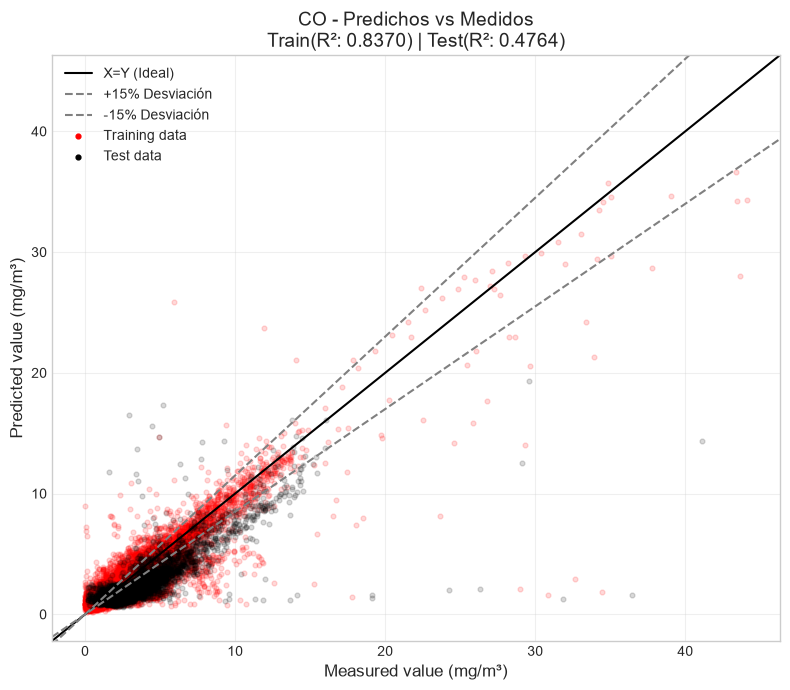


Generando gráfico: muestra del Train Set...


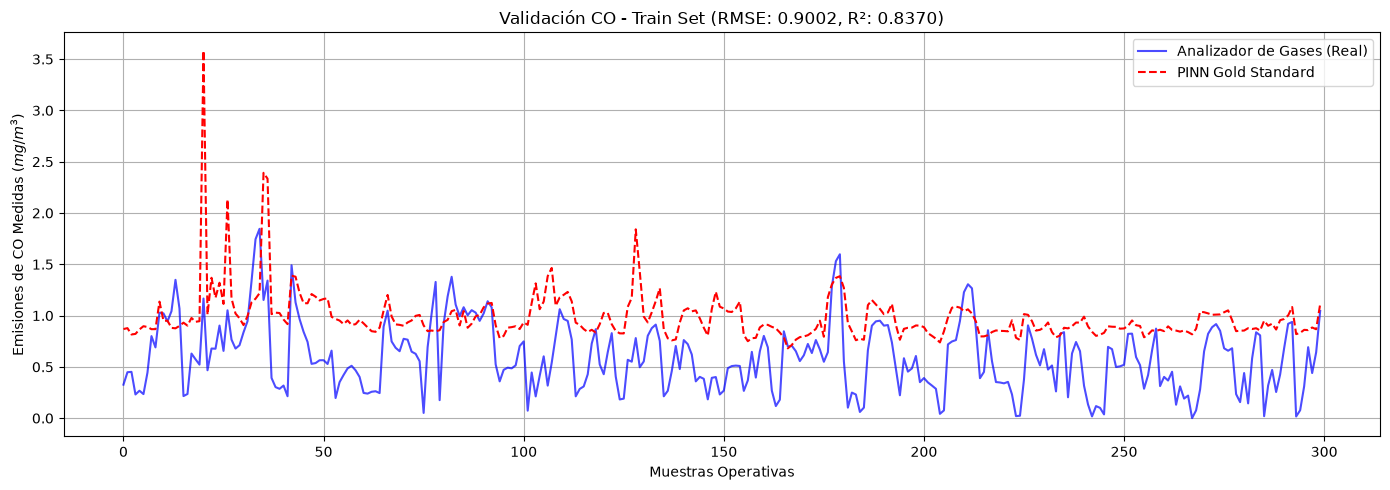


Generando gráfico: muestra del Test Set (Walk-forward)...


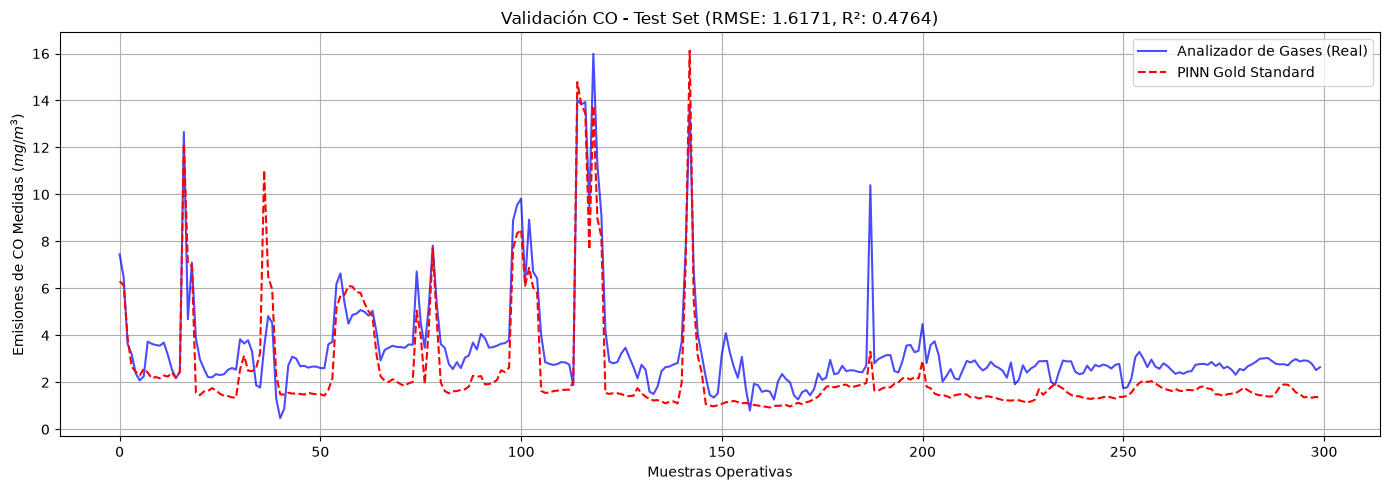

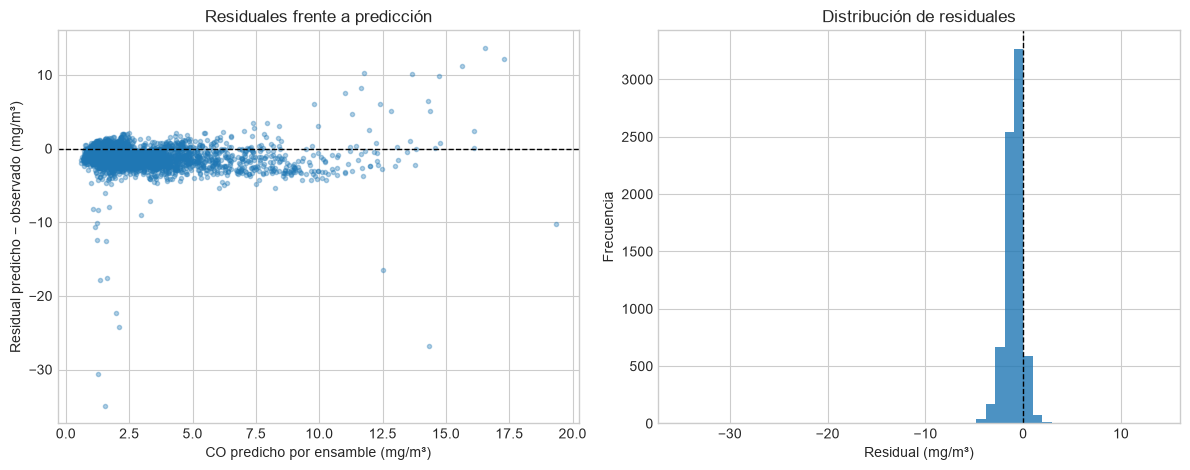

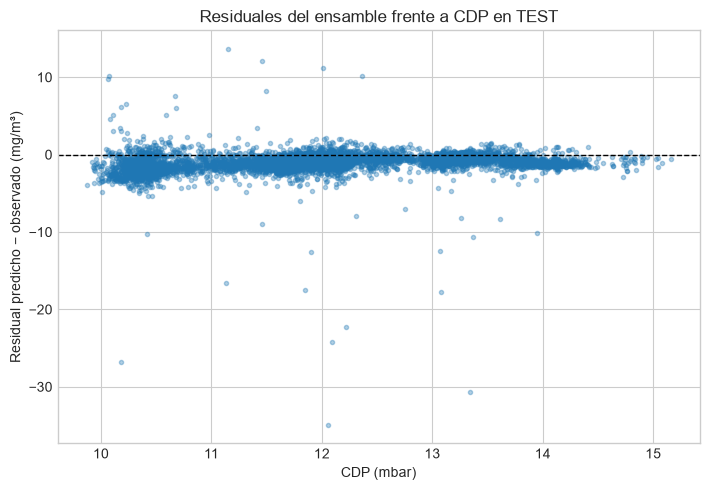

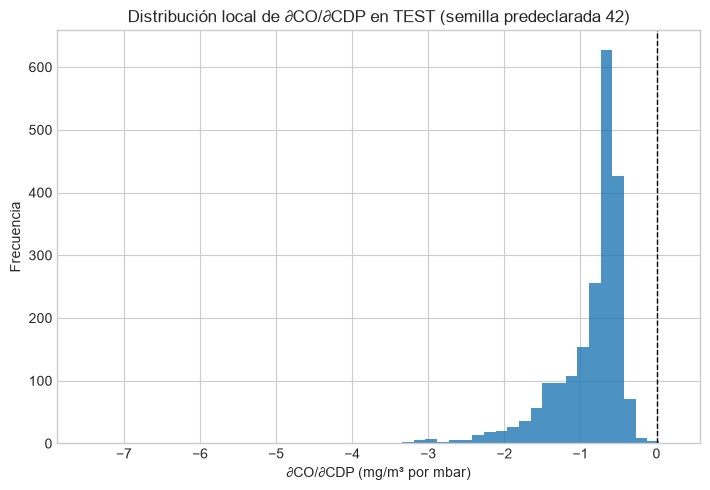

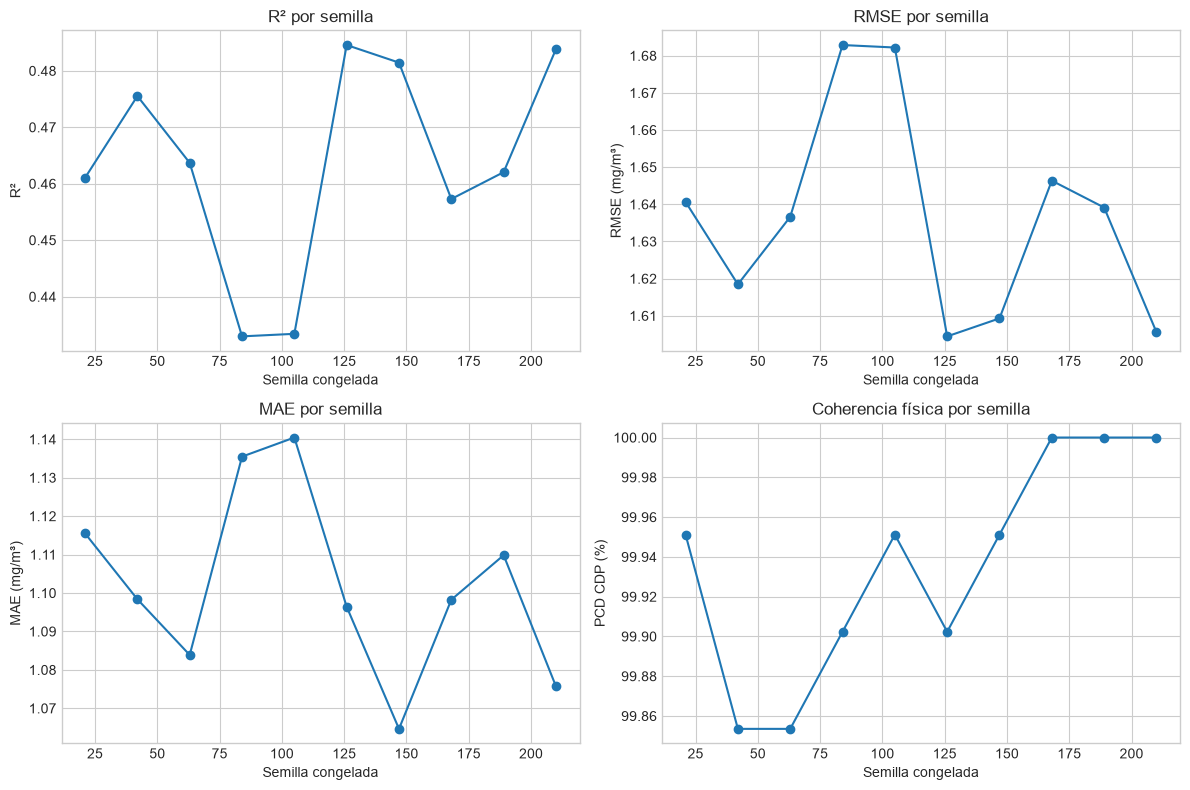

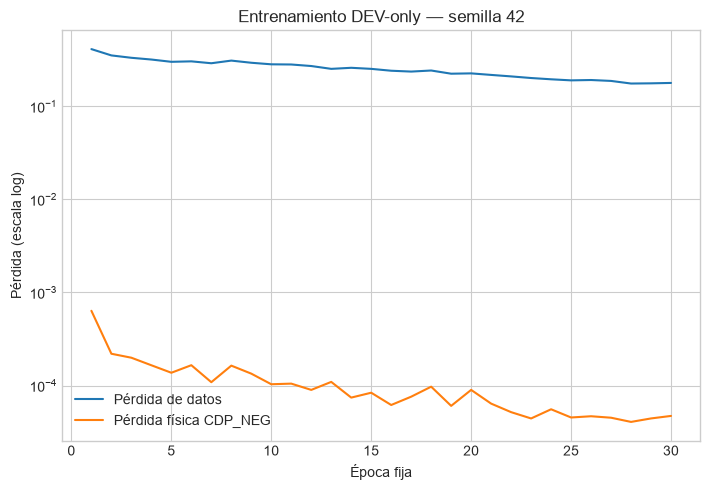

In [17]:
# [C-09.01] Figuras predictivas y físicas
def save_figure(figure: plt.Figure, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    figure.tight_layout()
    figure.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(figure)


plt.style.use("seaborn-v0_8-whitegrid")
observed = prediction_table["observed_CO_mg_m3"].to_numpy()
ensemble = prediction_table["pred_ensemble_mg_m3"].to_numpy()
residual = prediction_table["residual_ensemble_mg_m3"].to_numpy()

print("\nGenerando gráfico combinado de predichos vs. medidos para CO...")

# DEV se incorpora únicamente para reproducir la figura histórica. No interviene
# en la evaluación TEST ni modifica modelos, épocas, semillas o escaladores.
dev_seed_predictions = []
for final_seed in FINAL_SEEDS:
    model_path = PATHS.models / f"PINN_CO_WF_seed{final_seed}.pt"
    package, model, x_scaler, y_scaler = load_model_package(model_path, DEVICE)
    dev_seed_predictions.append(
        predict_physical(
            model,
            x_dev,
            x_scaler,
            y_scaler,
            package["config"],
            DEVICE,
        )
    )
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

dev_ensemble = np.column_stack(dev_seed_predictions).mean(axis=1)
dev_ensemble_metrics = regression_metrics(y_dev, dev_ensemble)

minimum_value = min(
    float(y_dev.min()),
    float(observed.min()),
    float(dev_ensemble.min()),
    float(ensemble.min()),
)
maximum_value = max(
    float(y_dev.max()),
    float(observed.max()),
    float(dev_ensemble.max()),
    float(ensemble.max()),
)
margin = (maximum_value - minimum_value) * 0.05
limits = [minimum_value - margin, maximum_value + margin]
limits_array = np.asarray(limits)

figure, axis = plt.subplots(figsize=(8, 7))
axis.plot(
    limits,
    limits,
    color="black",
    label="X=Y (Ideal)",
    linestyle="-",
    linewidth=1.5,
)
axis.plot(
    limits_array,
    limits_array * 1.15,
    color="gray",
    label="+15% Desviación",
    linestyle="--",
)
axis.plot(
    limits_array,
    limits_array * 0.85,
    color="gray",
    label="-15% Desviación",
    linestyle="--",
)
axis.scatter(
    y_dev,
    dev_ensemble,
    color="red",
    label="Training data",
    s=12,
    alpha=0.15,
)
axis.scatter(
    observed,
    ensemble,
    color="black",
    label="Test data",
    s=12,
    alpha=0.15,
)
axis.set_ylabel("Predicted value (mg/m³)", fontsize=12)
axis.set_xlabel("Measured value (mg/m³)", fontsize=12)
axis.set_xlim(limits)
axis.set_ylim(limits)
axis.set_title(
    "CO - Predichos vs Medidos\n"
    f"Train(R²: {dev_ensemble_metrics['R2']:.4f}) | "
    f"Test(R²: {ENSEMBLE_METRICS['R2']:.4f})",
    fontsize=14,
)
legend = axis.legend(loc="upper left", fontsize=10)
for legend_handle in legend.legend_handles:
    legend_handle.set_alpha(1.0)
axis.grid(True, alpha=0.3)
save_figure(figure, PATHS.figures_test / "01_paridad_ensamble_TEST.png")

OPERATIONAL_SAMPLE_ROWS = 300


def plot_co_operational_sample(
    y_true: np.ndarray,
    predicted: np.ndarray,
    split_type: str,
    metrics: dict,
    output_path: Path,
) -> None:
    """Reproduce para CO el panel histórico de series de este notebook."""
    sample_rows = min(OPERATIONAL_SAMPLE_ROWS, len(y_true), len(predicted))
    with plt.style.context("default"):
        figure, axis = plt.subplots(figsize=(14, 5))
        axis.plot(
            y_true[:sample_rows],
            label="Analizador de Gases (Real)",
            color="blue",
            alpha=0.7,
        )
        axis.plot(
            predicted[:sample_rows],
            label="PINN Gold Standard",
            color="red",
            linestyle="dashed",
        )
        axis.set_title(
            f"Validación CO - {split_type} "
            f"(RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f})"
        )
        axis.set_ylabel(r"Emisiones de CO Medidas ($mg/m^3$)")
        axis.set_xlabel("Muestras Operativas")
        axis.legend()
        axis.grid(True)
        save_figure(figure, output_path)


print("\nGenerando gráfico: muestra del Train Set...")
plot_co_operational_sample(
    y_dev,
    dev_ensemble,
    "Train Set",
    dev_ensemble_metrics,
    PATHS.figures_test / "02_serie_ensamble_DEV.png",
)

print("\nGenerando gráfico: muestra del Test Set (Walk-forward)...")
plot_co_operational_sample(
    observed,
    ensemble,
    "Test Set",
    ENSEMBLE_METRICS,
    PATHS.figures_test / "02_serie_ensamble_TEST.png",
)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(ensemble, residual, s=9, alpha=0.35)
axes[0].axhline(0, linestyle="--", color="black", linewidth=1)
axes[0].set(
    title="Residuales frente a predicción",
    xlabel="CO predicho por ensamble (mg/m³)",
    ylabel="Residual predicho − observado (mg/m³)",
)
axes[1].hist(residual, bins=50, alpha=0.8)
axes[1].axvline(0, linestyle="--", color="black", linewidth=1)
axes[1].set(
    title="Distribución de residuales",
    xlabel="Residual (mg/m³)",
    ylabel="Frecuencia",
)
save_figure(figure, PATHS.figures_test / "03_diagnostico_residuales_TEST.png")

figure, axis = plt.subplots(figsize=(7.2, 5.0))
axis.scatter(prediction_table["CDP"], residual, s=9, alpha=0.35)
axis.axhline(0, linestyle="--", color="black", linewidth=1)
axis.set(
    title="Residuales del ensamble frente a CDP en TEST",
    xlabel="CDP (mbar)",
    ylabel="Residual predicho − observado (mg/m³)",
)
save_figure(figure, PATHS.figures_test / "04_residuales_vs_CDP_TEST.png")

representative_gradient = physics_gradient_by_seed[REPRESENTATIVE_SEED]
figure, axis = plt.subplots(figsize=(7.2, 5.0))
axis.hist(representative_gradient, bins=50, alpha=0.8)
axis.axvline(0, linestyle="--", color="black", linewidth=1)
axis.set(
    title=(
        "Distribución local de ∂CO/∂CDP en TEST "
        f"(semilla predeclarada {REPRESENTATIVE_SEED})"
    ),
    xlabel="∂CO/∂CDP (mg/m³ por mbar)",
    ylabel="Frecuencia",
)
save_figure(figure, PATHS.figures_test / "05_gradiente_CDP_TEST_seed42.png")

figure, axes = plt.subplots(2, 2, figsize=(12, 8))
metric_panels = [
    ("R2", "R²", "R² por semilla"),
    ("RMSE", "RMSE (mg/m³)", "RMSE por semilla"),
    ("MAE", "MAE (mg/m³)", "MAE por semilla"),
    ("active_cdp_pcd_pct", "PCD CDP (%)", "Coherencia física por semilla"),
]
for axis, (column, ylabel, title) in zip(axes.flat, metric_panels):
    axis.plot(SEED_METRICS.seed, SEED_METRICS[column], "o-")
    axis.set(title=title, xlabel="Semilla congelada", ylabel=ylabel)
save_figure(figure, PATHS.figures_summary / "06_metricas_por_semilla.png")

representative_history = TRAINING_HISTORY.loc[
    TRAINING_HISTORY.seed.eq(REPRESENTATIVE_SEED)
]
figure, axis = plt.subplots(figsize=(7.2, 5.0))
axis.plot(
    representative_history.epoch,
    representative_history.loss_data,
    label="Pérdida de datos",
)
axis.plot(
    representative_history.epoch,
    representative_history.loss_physics,
    label="Pérdida física CDP_NEG",
)
axis.set_yscale("log")
axis.set(
    title=f"Entrenamiento DEV-only — semilla {REPRESENTATIVE_SEED}",
    xlabel="Época fija",
    ylabel="Pérdida (escala log)",
)
axis.legend()
save_figure(figure, PATHS.figures_summary / "07_perdidas_entrenamiento_seed42.png")


### C-09.02 — Huella computacional normalizada

**Objetivo:** caracterizar el costo estructural, de almacenamiento y de inferencia
del PINN definitivo sin mezclarlo con precisión predictiva.  
**Entradas:** checkpoint de la semilla representativa, TEST y escaladores congelados.  
**Salidas:** parámetros, memoria FP32, tamaño serializado, latencias CPU, throughput
y metadatos del hardware.  
**Control:** CPU, FP32, batch=1, 20 warm-ups y 200 repeticiones. La latencia del
motor se separa de la latencia end-to-end. El benchmark no altera pesos,
configuración, predicciones ni métricas TEST.


In [18]:
# [C-09.02] Huella computacional normalizada
def model_storage_metrics(model: nn.Module) -> dict:
    """Cuantifica parámetros, buffers y almacenamiento tensorial."""
    parameters = list(model.parameters())
    buffers = list(model.buffers())
    if any(parameter.dtype != torch.float32 for parameter in parameters):
        raise RuntimeError("El benchmark exige parámetros FP32")
    if any(
        buffer.is_floating_point() and buffer.dtype != torch.float32
        for buffer in buffers
    ):
        raise RuntimeError("El benchmark exige buffers flotantes FP32")
    trainable = sum(
        parameter.numel()
        for parameter in parameters
        if parameter.requires_grad
    )
    total = sum(parameter.numel() for parameter in parameters)
    buffer_elements = sum(buffer.numel() for buffer in buffers)
    parameter_bytes = sum(
        parameter.numel() * parameter.element_size()
        for parameter in parameters
    )
    buffer_bytes = sum(
        buffer.numel() * buffer.element_size()
        for buffer in buffers
    )
    return {
        "trainable_parameters": int(trainable),
        "total_parameters": int(total),
        "buffer_elements": int(buffer_elements),
        "state_tensor_elements": int(total + buffer_elements),
        "parameter_memory_fp32_mib": float(parameter_bytes / 2**20),
        "buffer_memory_fp32_mib": float(buffer_bytes / 2**20),
        "state_tensor_memory_fp32_mib": float(
            (parameter_bytes + buffer_bytes) / 2**20
        ),
    }


def serialized_state_dict_mib(model: nn.Module) -> float:
    """Mide el state_dict serializado; no representa RAM."""
    descriptor, temporary_name = tempfile.mkstemp(suffix=".pt")
    os.close(descriptor)
    temporary_path = Path(temporary_name)
    try:
        torch.save(model.state_dict(), temporary_path)
        return float(temporary_path.stat().st_size / 2**20)
    finally:
        temporary_path.unlink(missing_ok=True)


def latency_distribution_ms(
    operation,
    warmup: int = LATENCY_WARMUP,
    repetitions: int = LATENCY_REPETITIONS,
) -> dict:
    """Mide una operación CPU con warm-up y distribución de latencias."""
    for _ in range(warmup):
        operation()
    timings_ms = []
    for _ in range(repetitions):
        started = time.perf_counter()
        operation()
        timings_ms.append((time.perf_counter() - started) * 1000)
    return {
        "median_ms": float(np.median(timings_ms)),
        "p95_ms": float(np.quantile(timings_ms, 0.95)),
        "p99_ms": float(np.quantile(timings_ms, 0.99)),
    }


def benchmark_engine_cpu(
    model: nn.Module,
    standardized_sample: torch.Tensor,
) -> dict:
    """Mide exclusivamente X preprocesado -> salida del modelo."""
    model.eval()

    def operation() -> None:
        with torch.inference_mode():
            model(standardized_sample)

    values = latency_distribution_ms(operation)
    return {
        "engine_latency_cpu_median_ms": values["median_ms"],
        "engine_latency_cpu_p95_ms": values["p95_ms"],
        "engine_latency_cpu_p99_ms": values["p99_ms"],
    }


def benchmark_end_to_end_cpu(
    model: nn.Module,
    physical_sample: np.ndarray,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    config: dict,
) -> dict:
    """Mide validación, scaling, modelo e inverse scaling."""
    model.eval()

    def operation() -> None:
        if not np.isfinite(physical_sample).all():
            raise ValueError("La muestra end-to-end contiene NaN o infinito")
        standardized = x_scaler.transform(
            physical_sample
        ).astype(np.float32)
        tensor = torch.from_numpy(standardized)
        with torch.inference_mode():
            predicted_standard = model(tensor).numpy()
        target_inverse(
            predicted_standard,
            y_scaler,
            config["target_transform"],
        )

    values = latency_distribution_ms(operation)
    return {
        "end_to_end_latency_cpu_median_ms": values["median_ms"],
        "end_to_end_latency_cpu_p95_ms": values["p95_ms"],
        "end_to_end_latency_cpu_p99_ms": values["p99_ms"],
    }


def benchmark_throughput_cpu(
    model: nn.Module,
    standardized_batch: torch.Tensor,
    warmup: int = THROUGHPUT_WARMUP,
    repetitions: int = THROUGHPUT_REPETITIONS,
) -> dict:
    """Mide capacidad masiva sobre TEST completo preprocesado."""
    model.eval()
    with torch.inference_mode():
        for _ in range(warmup):
            model(standardized_batch)
        elapsed_seconds = []
        for _ in range(repetitions):
            started = time.perf_counter()
            model(standardized_batch)
            elapsed_seconds.append(time.perf_counter() - started)
    median_seconds = float(np.median(elapsed_seconds))
    return {
        "throughput_batch_rows": int(len(standardized_batch)),
        "throughput_cpu_samples_per_s": float(
            len(standardized_batch) / median_seconds
        ),
        "throughput_batch_median_ms": float(median_seconds * 1000),
    }


cpu_device = torch.device("cpu")
representative_path = (
    PATHS.models / f"PINN_CO_WF_seed{REPRESENTATIVE_SEED}.pt"
)
(
    representative_package,
    representative_model,
    representative_x_scaler,
    representative_y_scaler,
) = load_model_package(representative_path, cpu_device)
representative_model.eval()

x_test_physical = TEST_DATA[FEATURES].to_numpy(np.float32)
x_test_standardized = representative_x_scaler.transform(
    x_test_physical
).astype(np.float32)
x_test_cpu = torch.from_numpy(x_test_standardized)
x_sample_physical = x_test_physical[:1]
x_sample_cpu = x_test_cpu[:1]

FOOTPRINT = {
    **architecture_summary(representative_model, BEST_CONFIG),
    **model_storage_metrics(representative_model),
    "measurement_scope": "representative_frozen_seed_model",
    "representative_seed": REPRESENTATIVE_SEED,
    "ensemble_model_count": len(FINAL_SEEDS),
    "precision": "FP32",
    "benchmark_device": "cpu",
    "latency_batch_size": 1,
    "latency_warmup": LATENCY_WARMUP,
    "latency_repetitions": LATENCY_REPETITIONS,
    "throughput_warmup": THROUGHPUT_WARMUP,
    "throughput_repetitions": THROUGHPUT_REPETITIONS,
    "serialized_state_dict_mib": serialized_state_dict_mib(
        representative_model
    ),
    "checkpoint_package_mib": float(
        representative_path.stat().st_size / 2**20
    ),
    "ensemble_checkpoint_package_mib": float(
        sum(
            (
                PATHS.models / f"PINN_CO_WF_seed{seed}.pt"
            ).stat().st_size
            for seed in FINAL_SEEDS
        )
        / 2**20
    ),
    "cpu_model": platform.processor() or platform.machine(),
    "cpu_platform": platform.platform(),
    "cpu_physical_cores": psutil.cpu_count(logical=False),
    "cpu_logical_threads": psutil.cpu_count(logical=True),
    "torch_num_threads": torch.get_num_threads(),
    "torch_num_interop_threads": torch.get_num_interop_threads(),
    "engine_latency_definition": (
        "preprocessed_X_to_standardized_model_output"
    ),
    "end_to_end_latency_definition": (
        "finite_check_scaling_model_inverse_target"
    ),
    **benchmark_engine_cpu(representative_model, x_sample_cpu),
    **benchmark_end_to_end_cpu(
        representative_model,
        x_sample_physical,
        representative_x_scaler,
        representative_y_scaler,
        BEST_CONFIG,
    ),
    **benchmark_throughput_cpu(representative_model, x_test_cpu),
}

FOOTPRINT_TABLE = pd.DataFrame([FOOTPRINT])
COMPLEXITY = copy.deepcopy(FOOTPRINT)
COMPLEXITY_TABLE = FOOTPRINT_TABLE.copy()
atomic_csv(PATHS.tables / "computational_footprint.csv", FOOTPRINT_TABLE)
atomic_json(PATHS.tables / "computational_footprint.json", FOOTPRINT)
atomic_csv(PATHS.tables / "model_complexity.csv", COMPLEXITY_TABLE)

separator = "=" * 68
print(separator)
print("HUELLA COMPUTACIONAL - PINN CO WALK-FORWARD")
print(separator)
print("Complejidad estructural")
print(f"Parámetros entrenables       : {FOOTPRINT['trainable_parameters']:,}")
print(f"Parámetros totales           : {FOOTPRINT['total_parameters']:,}")
print(f"Elementos en buffers         : {FOOTPRINT['buffer_elements']:,}")
print("Almacenamiento")
print(
    "Memoria parámetros FP32    : "
    f"{FOOTPRINT['parameter_memory_fp32_mib']:.6f} MiB"
)
print(
    "State dict serializado     : "
    f"{FOOTPRINT['serialized_state_dict_mib']:.6f} MiB"
)
print("Inferencia CPU - batch = 1")
print(f"Warm-up                      : {FOOTPRINT['latency_warmup']}")
print(f"Repeticiones                 : {FOOTPRINT['latency_repetitions']}")
print(
    "Latencia motor mediana     : "
    f"{FOOTPRINT['engine_latency_cpu_median_ms']:.6f} ms"
)
print(
    "Latencia motor p95         : "
    f"{FOOTPRINT['engine_latency_cpu_p95_ms']:.6f} ms"
)
print(
    "Latencia motor p99         : "
    f"{FOOTPRINT['engine_latency_cpu_p99_ms']:.6f} ms"
)
print(
    "Latencia end-to-end mediana: "
    f"{FOOTPRINT['end_to_end_latency_cpu_median_ms']:.6f} ms"
)
print(
    "Latencia end-to-end p95    : "
    f"{FOOTPRINT['end_to_end_latency_cpu_p95_ms']:.6f} ms"
)
print(
    "Latencia end-to-end p99    : "
    f"{FOOTPRINT['end_to_end_latency_cpu_p99_ms']:.6f} ms"
)
print("Procesamiento por lotes")
print(
    "Throughput CPU             : "
    f"{FOOTPRINT['throughput_cpu_samples_per_s']:.3f} muestras/s"
)
print(separator)
display(FOOTPRINT_TABLE.T.rename(columns={0: "valor"}))


HUELLA COMPUTACIONAL - PINN CO WALK-FORWARD
Complejidad estructural
Parámetros entrenables       : 50,273
Parámetros totales           : 50,273
Elementos en buffers         : 0
Almacenamiento
Memoria parámetros FP32    : 0.191776 MiB
State dict serializado     : 0.195928 MiB
Inferencia CPU - batch = 1
Warm-up                      : 20
Repeticiones                 : 200
Latencia motor mediana     : 0.048900 ms
Latencia motor p95         : 0.068405 ms
Latencia motor p99         : 0.185359 ms
Latencia end-to-end mediana: 0.160550 ms
Latencia end-to-end p95    : 0.228215 ms
Latencia end-to-end p99    : 0.415300 ms
Procesamiento por lotes
Throughput CPU             : 4785948.114 muestras/s


,valor
input_nodes,9
hidden_layers,4
hidden_nodes,544
output_nodes,1
total_nodes,554
linear_layers,5
trainable_parameters,50273
MACs_per_inference,49728
FLOPs_approx,99456
fourier_features,0


## SEC-10 — Persistencia, manifiesto y cierre

### C-10.01 — Copia trazable de configuración y reporte técnico

**Objetivo:** preservar las fuentes `FROZEN` junto al resultado final.  
**Entradas:** configuración, política, auditorías, métricas y complejidad.  
**Salidas:** copias verificables, README e informe técnico.  
**Control:** las copias deben conservar el hash de los archivos fuente.


In [19]:
# [C-10.01] Copia trazable de configuración y reporte técnico
import shutil

source_config = FROZEN["artifact_paths"]["best_config"]
source_policy = FROZEN["artifact_paths"]["training_policy"]
copied_config = PATHS.configs / source_config.name
copied_policy = PATHS.configs / source_policy.name
shutil.copy2(source_config, copied_config)
shutil.copy2(source_policy, copied_policy)
if sha256_file(source_config) != sha256_file(copied_config):
    raise RuntimeError("La copia de BEST_CONFIG no conserva su hash")
if sha256_file(source_policy) != sha256_file(copied_policy):
    raise RuntimeError("La copia de FINAL_TRAINING_POLICY no conserva su hash")

input_snapshot = {
    "status": "VERIFIED",
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "protocol_version": PROTOCOL_VERSION,
    "opt_version": OPT_VERSION,
    "opt_stop_policy": FROZEN["stop_policy"],
    "opt_frozen_manifest_sha256": (
        FROZEN["upstream_contract"]["opt_frozen_manifest_sha256"]
    ),
    "consumer_notebook": CURRENT_NOTEBOOK_NAME,
    "authorized_producers": [PROTOCOL_NOTEBOOK_NAME, OPT_NOTEBOOK_NAME],
    "protocol_artifact_manifest_sha256": FROZEN["protocol_manifest_sha256"],
    "config_hash": BEST_CONFIG["config_hash"],
    "physics_mode": PHYSICS_MODE,
    "physics_feature": PHYSICS_FEATURE,
    "monotonic_constraint": MONOTONIC_CONSTRAINT,
    "row_assignment_sha256": FROZEN["assignment_hash"],
    "fold_assignment_sha256": FROZEN["fold_hash"],
    "best_config_file_sha256": sha256_file(source_config),
    "final_policy_file_sha256": sha256_file(source_policy),
    "pre_test_gate_sha256": PRE_TEST_GATE["gate_sha256"],
}
atomic_json(PATHS.configs / "FROZEN_INPUT_SNAPSHOT_R3F_STD.json", input_snapshot)

readme = """# Ejecución en Google Colab

1. Conserve la estructura canónica Turbine_Emissions_PINN.
2. Verifique que PROTOCOL R1 y la campaña CO OPT R3 estén FROZEN.
3. Abra 04_Gold_Standard_PINN_CO_WF_FINAL - R3F_STD.ipynb.
4. Seleccione GPU y use Runtime → Run all.
5. No ejecute celdas fuera de orden.

El notebook acepta solo CDP_NEG, entrena diez modelos con DEV completo antes de
abrir TEST y evalúa ∂CO/∂CDP ≤ 0. Los resultados quedan en
models/wf/work_pinn_co_wf_final_r3_std/.
"""
atomic_text(
    PATHS.reports / "README_EJECUCION_COLAB_CO_WF_FINAL_R3F_STD.md",
    readme,
)

r2_summary = MULTISEED_SUMMARY.loc[MULTISEED_SUMMARY.metric.eq("R2")].iloc[0]
rmse_summary = MULTISEED_SUMMARY.loc[MULTISEED_SUMMARY.metric.eq("RMSE")].iloc[0]
pcd_summary = MULTISEED_SUMMARY.loc[
    MULTISEED_SUMMARY.metric.eq("active_cdp_pcd_pct")
].iloc[0]
violation_summary = MULTISEED_SUMMARY.loc[
    MULTISEED_SUMMARY.metric.eq("active_cdp_violation_pct")
].iloc[0]
gradient_summary = MULTISEED_SUMMARY.loc[
    MULTISEED_SUMMARY.metric.eq("dCO_dCDP_phys_median")
].iloc[0]
report = f"""# Informe técnico — CO walk-forward FINAL R3F_STD

## Diseño ejecutado

Se consumió la configuración {BEST_CONFIG['config_hash']} seleccionada por CO OPT R3,
exclusivamente con modo `{PHYSICS_MODE}` y {FINAL_EPOCHS} épocas congeladas. La
política adaptativa R3 se verificó solo como procedencia y no intervino en TEST. Se
entrenaron {len(FINAL_SEEDS)} modelos con todo DEV. Escaladores, escalas físicas
robustas, sintéticos CDP y pesos quedaron ajustados antes de abrir TEST.

## Resultado TEST

- R² multisemilla: media={r2_summary['mean']:.6f}, DE={r2_summary['std']:.6f}.
- RMSE multisemilla: media={rmse_summary['mean']:.6f} mg/m³,
  DE={rmse_summary['std']:.6f} mg/m³.
- PCD de ∂CO/∂CDP≤0: media={pcd_summary['mean']:.6f} %,
  DE={pcd_summary['std']:.6f} %.
- Violación CDP: media={violation_summary['mean']:.6f} %.
- Mediana de ∂CO/∂CDP: media entre semillas={gradient_summary['mean']:.6f}.
- R² del ensamble predeclarado: {ENSEMBLE_METRICS['R2']:.6f}.
- RMSE del ensamble: {ENSEMBLE_METRICS['RMSE']:.6f} mg/m³.

## Huella computacional

- Semilla representativa: {REPRESENTATIVE_SEED}.
- Parámetros entrenables: {FOOTPRINT['trainable_parameters']}.
- Memoria teórica FP32: {FOOTPRINT['parameter_memory_fp32_mib']:.6f} MiB.
- State dict serializado: {FOOTPRINT['serialized_state_dict_mib']:.6f} MiB.
- Latencia CPU del motor, batch=1: mediana=
  {FOOTPRINT['engine_latency_cpu_median_ms']:.6f} ms,
  p95={FOOTPRINT['engine_latency_cpu_p95_ms']:.6f} ms.
- Latencia CPU end-to-end, batch=1: mediana=
  {FOOTPRINT['end_to_end_latency_cpu_median_ms']:.6f} ms,
  p95={FOOTPRINT['end_to_end_latency_cpu_p95_ms']:.6f} ms.
- Throughput CPU: {FOOTPRINT['throughput_cpu_samples_per_s']:.3f} muestras/s.

## Interpretación

La derivada negativa respecto a CDP expresa sensibilidad local de la superficie
aprendida; no establece causalidad ni una ley global. Esta evaluación no demuestra
transferencia temporal, extrapolación ni conformidad regulatoria. No se evaluaron
restricciones físicas respecto a TIT ni combinaciones duales.
"""
atomic_text(
    PATHS.reports / "INFORME_TECNICO_CO_WF_FINAL_R3F_STD.md",
    report,
)


### C-10.02 — Manifiesto final y hashes de artefactos

**Objetivo:** cerrar una cadena auditable desde PROTOCOL R1 y CO OPT R3 hasta TEST.  
**Entradas:** modelos, tablas, figuras, auditorías, configuración y reportes.  
**Salidas:** hashes y `MANIFEST_CO_WF_FINAL_R3F_STD.json`.  
**Control:** `COMPLETE` exige diez modelos y todos los artefactos finales.


In [20]:
# [C-10.02] Manifiesto final y hashes de artefactos
required_final_files = [
    PATHS.audit / "ENVIRONMENT_CO_WF_FINAL_R3F_STD.json",
    PATHS.audit / "FROZEN_INPUT_AUDIT_CO_WF_FINAL_R3.csv",
    PATHS.audit / "UPSTREAM_INPUT_CONTRACT_R3F_STD.json",
    PATHS.audit / "TARGET_ACCESS_AUDIT_PRE_TEST_R3F_STD.json",
    PATHS.audit / "PRETRAINING_CHECKS_R3F_STD.csv",
    PATHS.audit / "PRE_TEST_GATE_R3F_STD.json",
    PATHS.audit / "TEST_ACCESS_AUDIT_R3F_STD.json",
    PATHS.configs / "BEST_CONFIG_CO_WF_R3.json",
    PATHS.configs / "FINAL_TRAINING_POLICY_CO_WF_R3.json",
    PATHS.configs / "FROZEN_INPUT_SNAPSHOT_R3F_STD.json",
    PATHS.tables / "training_history_by_seed.csv",
    PATHS.tables / "training_summary_by_seed.csv",
    PATHS.tables / "test_metrics_by_seed.csv",
    PATHS.tables / "test_predictions.csv",
    PATHS.tables / "test_metrics_ensemble.json",
    PATHS.tables / "test_summary_multiseed.csv",
    PATHS.tables / "model_complexity.csv",
    PATHS.tables / "computational_footprint.csv",
    PATHS.tables / "computational_footprint.json",
    PATHS.reports / "README_EJECUCION_COLAB_CO_WF_FINAL_R3F_STD.md",
    PATHS.reports / "INFORME_TECNICO_CO_WF_FINAL_R3F_STD.md",
]
required_final_files.extend(
    PATHS.models / f"PINN_CO_WF_seed{seed}.pt"
    for seed in FINAL_SEEDS
)
required_figure_files = [
    PATHS.figures_test / "01_paridad_ensamble_TEST.png",
    PATHS.figures_test / "02_serie_ensamble_DEV.png",
    PATHS.figures_test / "02_serie_ensamble_TEST.png",
    PATHS.figures_test / "03_diagnostico_residuales_TEST.png",
    PATHS.figures_test / "04_residuales_vs_CDP_TEST.png",
    PATHS.figures_test / "05_gradiente_CDP_TEST_seed42.png",
    PATHS.figures_summary / "06_metricas_por_semilla.png",
    PATHS.figures_summary / "07_perdidas_entrenamiento_seed42.png",
]
required_final_files.extend(required_figure_files)
missing_final = [str(path) for path in required_final_files if not path.is_file()]
if missing_final:
    raise FileNotFoundError("Artefactos finales ausentes: " + str(missing_final))

artifact_hashes = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(PATHS.work)),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in sorted(set(required_final_files))
    ]
)
atomic_csv(PATHS.audit / "HASHES_CO_WF_FINAL_R3F_STD.csv", artifact_hashes)

if not (
    TEST_ACCESS_AUDIT.get("opened_once") is True
    and int(TEST_ACCESS_AUDIT.get("access_count", 0)) == 1
    and _TEST_HAS_BEEN_OPENED
    and _TEST_ACCESS_COUNT == 1
):
    raise RuntimeError("No se puede declarar COMPLETE sin apertura TEST única")


FINAL_MANIFEST = {
    "status": "COMPLETE",
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "scope": "WF04 prospective annual holdout: 2011-2014 to 2015",
    "protocol_version": PROTOCOL_VERSION,
    "opt_version": OPT_VERSION,
    "opt_stop_policy": FROZEN["stop_policy"],
    "opt_stop_reason": FROZEN["stop_policy"]["stop_reason"],
    "producer_notebook": CURRENT_NOTEBOOK_NAME,
    "upstream_notebooks": [
        PROTOCOL_NOTEBOOK_NAME,
        OPT_NOTEBOOK_NAME,
    ],
    "input_contract": "PROTOCOL_R1_AND_OPT_R3_FROZEN_ONLY",
    "protocol_artifact_manifest_sha256": (
        FROZEN["protocol_manifest_sha256"]
    ),
    "config_frozen_using_dev_only": True,
    "config_hash": BEST_CONFIG["config_hash"],
    "physics_mode": BEST_CONFIG["physics_mode"],
    "physics_feature": PHYSICS_FEATURE,
    "monotonic_constraint": MONOTONIC_CONSTRAINT,
    "active_features": [PHYSICS_FEATURE],
    "physics_scale_quantiles": list(PHYSICS_SCALE_QUANTILES),
    "physics_scale_policy": PHYSICS_SCALE_POLICY,
    "provenance_trial_number": BEST_CONFIG["provenance_trial_number"],
    "row_assignment_sha256": FROZEN["assignment_hash"],
    "fold_assignment_sha256": FROZEN["fold_hash"],
    "final_epochs": FINAL_EPOCHS,
    "final_seeds": FINAL_SEEDS,
    "representative_seed_predeclared": REPRESENTATIVE_SEED,
    "ensemble_rule_predeclared": ENSEMBLE_RULE,
    "scheduler_final_policy": (
        "training_total_loss_only"
        if BEST_CONFIG["lr_scheduler"] == "reduce_on_plateau"
        else BEST_CONFIG["lr_scheduler"]
    ),
    "dev_rows": len(DEV_DATA),
    "test_rows": len(TEST_DATA),
    "models_frozen_before_test": True,
    "test_opened_once": (
        TEST_ACCESS_AUDIT["opened_once"]
        and TEST_ACCESS_AUDIT["access_count"] == 1
    ),
    "test_access_count": TEST_ACCESS_AUDIT["access_count"],
    "test_metrics_computed": True,
    "model_count": len(FINAL_SEEDS),
    "training_elapsed_seconds": FINAL_TRAINING_SECONDS,
    "environment": ENVIRONMENT,
    "ensemble_metrics": ENSEMBLE_METRICS,
    "computational_footprint": FOOTPRINT,
    "artifact_count": len(artifact_hashes),
    "artifacts": artifact_hashes.to_dict(orient="records"),
    "limitations": [
        "No demuestra generalización más allá de la frontera anual 2015.",
        "No demuestra desempeño fuera del periodo y dominio observados.",
        "No equivale a certificación PEMS, RATA ni homologación regulatoria.",
    ],
}
atomic_json(PATHS.work / "MANIFEST_CO_WF_FINAL_R3F_STD.json", FINAL_MANIFEST)

print(
    {
        "estado": FINAL_MANIFEST["status"],
        "CHK-10": "PASS",
        "modelos": FINAL_MANIFEST["model_count"],
        "artefactos": FINAL_MANIFEST["artifact_count"],
        "TEST abierto una vez": FINAL_MANIFEST["test_opened_once"],
        "salida": str(PATHS.work),
    }
)


{'estado': 'COMPLETE', 'CHK-10': 'PASS', 'modelos': 10, 'artefactos': 39, 'TEST abierto una vez': True, 'salida': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\wf\\work_pinn_co_wf_final_r3_std'}

## Resumen ejecutivo

La ejecución se considera completa únicamente cuando el manifiesto final declara:

- configuración congelada con DEV;
- diez modelos entrenados y recargados antes de TEST;
- una sola apertura de TEST;
- métricas individuales y agregadas sin selección post hoc;
- predicción ensamble bajo regla predeclarada;
- hashes de todos los artefactos;
- alcance limitado a predicción prospectiva walk-forward intradominio.

Las tablas y figuras deben interpretarse junto con el informe técnico. Un R² alto no
sustituye el análisis de error, estabilidad multisemilla, coherencia física,
complejidad computacional y limitaciones de validez externa.


## Registro de versión

R3F_STD consume exclusivamente WF_PROTOCOL_R1 y CO_WF_OPT_R3_POC_EFFICIENT FROZEN.
Entrena diez semillas con 2011–2014, autentica sus checkpoints, abre 2015 una
sola vez y registra el SHA‑256 del archivo únicamente después del gate. No existe
selección post hoc de semillas, épocas, configuración o ensamble.
